# 01 Final Model Evaluation
**Note:** In all but the last set of LSTM model notebooks, we were using the wrong version of the dataset. This final model evaluation will be focused on the last model that we tested after correcting for the data. Specifically, we will be evaluating our sliding window model not only with the current test set, but also new data that we obtain from yfinance in 2025.

## Imports

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import initializers
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.optimizers import SGD
import keras_tuner as kt
from keras_tuner import HyperParameters

import os
import sys
import warnings

# Data Loading and Initial Feature Engineering for LSTM Model

## Getting S&P500 Table Data

In [4]:
sp500_tables = pd.read_csv('../SP500_Tickers_March_2025.csv', index_col='Unnamed: 0')
sp500_tables.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## Loading in Data

In [5]:
# Loading in stock data
data = pd.read_csv("../SP500_4y_day_data.csv", index_col='Date', parse_dates=True)

In [6]:
# Converting Date_col to datetime format
data['Date_col'] = pd.to_datetime(data['Date_col'])

In [7]:
data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank
Date,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0
...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0


## Feature Engineering
Deriving multiple different features and outcome variables we can use in our model.

In [8]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,True,2
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,True,2
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,True,2
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,False,1


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [9]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,2,-0.386760,0.191515,0.819730,0.817589,115.875028,116.995388,114.092184,115.582756,2030700.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,2,0.177242,2.958772,0.118571,2.742242,115.426870,117.219451,115.027432,116.527748,2344000.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,2,4.751879,2.906048,4.991124,2.660925,115.631454,120.687707,115.163820,119.723221,2428500.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,1,1.737320,0.125518,1.401992,0.713386,121.126122,124.194950,120.911790,122.908966,1775900.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [10]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097539,124.506722,123.035631,124.068314,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419037,125.597856,124.078058,124.808731,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477480,125.461455,123.162270,123.727325,1612100.0,13.0,-0.750155,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805281,124.506729,123.045382,123.074608,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425324,124.194968,121.223560,122.246506,1365400.0,15.0,-1.178819,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265994,122.704395,120.678000,120.726707,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934108,119.830399,115.066411,115.738632,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933484,119.508910,115.719152,118.427513,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001684,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086527,118.554161,116.206261,117.073326,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [11]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191505,126.007032,122.977180,124.847694,1746800.0,6.0,1.656190,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023060,125.081511,122.947943,123.698105,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175467,124.750267,123.474019,123.707840,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990362,124.886660,122.577731,122.782318,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data['GICS Sector'] = data['GICS Sector'].fillna('Other')

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


In [13]:
# Getting date index column:
date_index = data.index.sort_values()

# Dropping duplicates:
date_index = date_index.drop_duplicates()

date_index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1005, freq=None)

## Selecting Base Features and Normalizing Data
Of the features we created, we select only the ones that we intend on using.

In [14]:
data.columns

Index(['Date_col', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rank',
       'Close_Open_Diff', 'Close_Open_Diff_Perc', 'Close_Open_Diff_Binary',
       'Close_Open_Diff_Ternary', 'Growth Rate_Open', 'Growth Rate_High',
       'Growth Rate_Low', 'Growth Rate_Close', 'PDO', 'PDH', 'PDL', 'PDC',
       'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Volume_14D', 'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_14', 'SMA_50',
       'SMA_200', 'EMA_9', 'EMA_20', 'SMA_prev_14', 'SMA_prev_50',
       'SMA_prev_200', 'EMA_prev_9', 'EMA_prev_20', 'RSI_14', 'RSI_prev_14',
       'ATR_14', 'NATR_14', 'GICS Sector'],
      dtype='object')

In [15]:
# Getting a copy of the data to work with so we don't ruin original
data_small = data.copy()

# Removing BIIB ticker in general (since it's missing data for one of the trading days)
data_small = data_small[data_small['Ticker'] != 'BIIB']

# If rank is less than or equal to the number of NA_days, drop the row (since there will be NaN data)
NA_days = 50  # Choosing 50 for SMA_prev_50
data_small = data_small[data_small['rank'] > NA_days]

# Only keeping certain columns
data_small_columns_keep = ['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold',
    'Daily_Range_Gap_Up', 'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary', 'Avg_Vol_Prev_14D', 'Vol_Change',
    'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14', 'GICS Sector', 'Close_Open_Diff_Perc',
    'Close_Open_Diff_Ternary']

data_small = data_small[data_small_columns_keep]

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,167.796289,167.735657,169.605319,165.838671,167.744599,5.939897e+06,0.000309,0.001013,-0.000990,5.951962e+06,0.023919,167.312294,165.962688,167.479749,167.087536,51.783003,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.010000,1.010000,1.040000,0.780000,0.980000,6.300000e+03,-0.388039,0.000000,-0.386389,1.150000e+04,-0.915551,1.055000,1.203000,1.059442,1.095938,3.203542,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,51.142663,51.130001,51.703654,50.546797,51.130585,9.969000e+05,-0.003835,0.000000,0.000000,1.094914e+06,-0.263134,51.035951,50.821200,51.097153,51.034005,43.036001,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,97.997940,97.980003,99.150002,96.781114,97.964836,2.042700e+06,0.000411,0.000000,0.000000,2.154914e+06,-0.083369,97.879983,97.531522,97.929508,97.831366,51.785360,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,187.732867,187.665114,189.720001,185.619995,187.674515,4.692700e+06,0.004637,0.000000,0.000000,4.816121e+06,0.161837,187.518051,186.307378,187.644120,187.424250,60.554521,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,9914.169922,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,0.536680,0.391608,0.000000,7.066849e+08,25.587868,9677.040737,9442.719980,9744.845871,9637.574378,96.316095,18.195811,32.653064,2.000000
std,NaN,354.722275,354.475111,358.475832,350.625212,354.573813,2.411370e+07,0.011125,0.004844,0.005323,2.313540e+07,0.534852,352.761797,347.020647,353.412287,351.684981,12.172738,0.911041,1.619073,0.828860


In [16]:
# Getting some percent changes for the PDC compared to PDO for the first 5 values of data_small
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']
# These values will be a good litmus test to confirm that our normalization kept our percent differences between price values

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [17]:
# Doing the same, but for volume
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [18]:
# Defining a function to normalize the prices/volume to the max (*2) of every ticker
def normalize_to_max_per_ticker(df, col_list):
    df_normalized = df.copy()

    # Grouping by Ticker and getting the max values for either price or volume by ticker
    max_vals = df_normalized.groupby('Ticker')[col_list].transform('max').max(axis=1)

    # Applying normalization to entire df by dividing by max values for each ticker and then multiplying by 2
    df_normalized[col_list] = df_normalized[col_list].div(max_vals, axis=0) * 2

    return df_normalized

# Note: We normalize to the maximum (instead of using MinMax) of each ticker in order to preserve the same % changes as the unnormalized
# value. In our case, our normalized maximum will be 2, so our values will range from (down to) 0 to 2

In [19]:
# Normalizing the following columns to the global maximum prices (by percent compared to max price) for each ticker 
# ^e.g., if OHLC for a day is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively for that day
price_cols_to_norm = ['Open', 'PDO', 'PDH', 'PDL', 'PDC', 'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20']
data_small = normalize_to_max_per_ticker(data_small, price_cols_to_norm)

# Normalizing volumes for all dates to the global maximum volume (by percent compared to max volume) for each ticker
volume_cols_to_norm = ['PDV', 'Avg_Vol_Prev_14D']
data_small = normalize_to_max_per_ticker(data_small, volume_cols_to_norm)

# Normalizing the following columns as percent (currently these are decimal changes) (except Vol_Change)
cols_to_perc = ['Gap_from_PDC', 'Daily_Range_Gap_Up', 'Daily_Range_Gap_Down']
data_small.loc[:, cols_to_perc] = data_small.loc[:, cols_to_perc] * 100

# Normalizing RSI to be between 0 and 1
data_small.loc[:, ['RSI_prev_14']] = data_small.loc[:, ['RSI_prev_14']] / 100

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,1.352334,1.352055,1.367110,1.336596,1.351941,0.331648,0.030902,0.101300,-0.098990,0.332086,0.023919,1.349815,1.342335,1.350641,1.348760,0.517830,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,0.053784,0.053784,0.056452,0.052552,0.053707,0.008487,-38.803893,0.000000,-38.638898,0.013925,-0.915551,0.063100,0.073716,0.060571,0.069261,0.032035,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,1.126022,1.125793,1.140061,1.112043,1.126120,0.181249,-0.383452,0.000000,0.000000,0.206541,-0.263134,1.125616,1.122068,1.126414,1.126401,0.430360,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,1.391997,1.391661,1.407153,1.375842,1.391571,0.287909,0.041106,0.000000,0.000000,0.315782,-0.083369,1.389664,1.383033,1.390428,1.389124,0.517854,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,1.615531,1.615151,1.631728,1.597817,1.614908,0.424620,0.463727,0.000000,0.000000,0.437228,0.161837,1.611993,1.602763,1.613052,1.610022,0.605545,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,2.000000,2.000000,2.000000,1.991389,1.999860,2.000000,53.667959,39.160845,0.000000,1.396082,25.587868,1.993995,2.000000,1.994551,2.000000,0.963161,18.195811,32.653064,2.000000
std,NaN,0.345995,0.345914,0.347798,0.343587,0.345700,0.222903,1.112548,0.484430,0.532302,0.169022,0.534852,0.343052,0.335889,0.343385,0.340425,0.121727,0.911041,1.619073,0.828860


In [20]:
# Double checking data_small shows us that we do indeed keep % differences between price features on the same day even after normalization
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [21]:
# And we see that we also keep % differences between the two volume features on the same day after normalization
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [22]:
# Ordering by date, and then by ticker to get the right splits for train/val/test
data_small = data_small.sort_values(by=['Date_col', 'Ticker'])

## Creating Dummy Variables for GICS Sector

In [23]:
# Getting a copy of data_small called data_smaller
data_smaller = data_small.copy()

In [24]:
# Getting dummy variables for GICS Sector
sector_dummy = pd.get_dummies(
    data_smaller['GICS Sector'],
    drop_first = False
)
print("Number of data_smaller dummy variables:", data_smaller['GICS Sector'].nunique())
print("Shape of data_smaller dummy variable for GICS Sector:",
      sector_dummy.shape, '\n')

# Adding the dummy variables to data_smaller
data_smaller = pd.concat(
    [data_smaller, sector_dummy],
    axis=1
)

Number of data_smaller dummy variables: 12
Shape of data_smaller dummy variable for GICS Sector: (453625, 12) 



In [25]:
# Checking to make sure dummies were created correctly
data_smaller.head(3)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391718,1.359954,1.366062,0.274100,-0.536577,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-17,2021-03-17,AAL,1.848984,1.924875,1.935608,1.863549,1.875814,0.577977,-1.430317,False,...,False,False,False,False,False,False,False,True,False,False
2021-03-17,2021-03-17,AAP,1.455625,1.470280,1.472615,1.427039,1.442258,0.090444,0.926817,False,...,False,False,False,False,False,False,False,True,False,False


In [26]:
# Removing GICS Sector since we've converted it to one-hot encoding
data_smaller = data_smaller.drop("GICS Sector", axis = 1)

print("Shape of data_smaller after removing original GICS Sector feature:",
      data_smaller.shape)

Shape of data_smaller after removing original GICS Sector feature: (453625, 36)


# Final LSTM Sliding Model (896/3/1 Train/Val/Test Split)
Our final chosen model involves using a training, validation, and test split of 896/3/1 days, respectively. Additionally, this model consists of a sequence length of 50 days, only 1 LSTM layer (128 units) and 1 dropout layer, and it will slide across our entire dataset. We have already tested the results of this model in the previous notebook, but we'll ultimately download more data from 2025 as our final test set to truly evaluate model performance.

## Generating X continuous series sequences and Y continuous labels for LSTM model
Here, we generate the correct X series sequences and respective Y continuous labels, ordered first by the date, and then by the ticker.

The following is the **corrected** function used to create our X and Y sequences in the LSTM model, with the "new addition" code at the bottom re-ordering the data first by date, and then by ticker:

In [27]:
# Function for creating sequences for LSTM model
def create_sequences_grouped(df, seq_length, group_col, target_col, drop_cols):
    """Create LSTM sequences separately for each unique ticker in the dataset."""
    X, Y = [], []
    num_tickers = df['Ticker'].nunique()
    
    # Group data by unique time series identifier (i.e., 'Ticker')
    grouped = df.groupby(group_col)
    
    for _, group in grouped:
        # Sorting by Date_col and removing the 'Ticker' column and dropped columns
        group = group.sort_values(by='Date_col')
        group = group.drop(columns=drop_cols)
        group = group.drop(columns=[group_col])

        # Getting feature and label columns
        feature_cols = group.drop(columns=[target_col]).columns
        feature_data = group[feature_cols].values
        labels = group[target_col].values
        
        # Creating sequences for this group only
        for i in range(len(group) - seq_length + 1):
            X.append(feature_data[i:i+seq_length])  # Collecting seq_length time steps
            Y.append(labels[i+seq_length-1])   # Target label is the most recent time step

    # Converting dtypes to the correct dtype
    X = np.array(X)
    X = X.astype(np.float32)
    Y = np.array(Y)
    Y = Y.astype(np.int32)

    # NEW ADDITION: Correctly re-ordering data first by the date, and THEN by the ticker
    indices_by_date_then_ticker = np.arange(X.shape[0]).reshape((num_tickers, -1)).flatten('F')
    X = X[indices_by_date_then_ticker]
    Y = Y[indices_by_date_then_ticker]
    
    return X, Y

In [28]:
# Creating sequences for LSTM model
seq_length = 50
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [29]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (430350, 50, 32)
Shape of Y_data_smaller: (430350,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 50
Number of sequences assuming the above seq_length: 906
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 430350
Total number of data sequences achieved: 430350


## Defining functions for splitting the dataset and building/compiling the LSTM model

We use the following function to constantly generate new training, validation, and test data splits as we slide our window:

In [30]:
# Defining function to split sequence data into train, val, test splits with split size (in terms of # of days)
def train_val_test_seq_split(X_window, Y_window, num_tickers, train_size, val_size, test_size):
    X_data = X_window.copy()
    Y_data = Y_window.copy()

    if (X_data.shape[0]/num_tickers) != (train_size + val_size + test_size):
        print("Train + val + test sizes do not much number of dates")
        return None

    X_train = X_data[:(num_tickers * train_size)]
    Y_train = Y_data[:(num_tickers * train_size)]
    X_val = X_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    Y_val = Y_data[(num_tickers * train_size):(num_tickers * (train_size + val_size))]
    X_test = X_data[(num_tickers * (train_size + val_size)):]
    Y_test = Y_data[(num_tickers * (train_size + val_size)):]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

We use the following function to rebuild, compile, and run our LSTM model for each sliding train/val/test window:

In [31]:
# Defining a function to create the LSTM model for sliding train, val, and test windows
def build_LSTM_model_slide(seq_length,
                     num_features,
                     n_classes,
                     LSTM_units=256,
                     learning_rate=0.01,
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=LSTM_units, return_sequences=False, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

## (Initial Window) Running the LSTM model with the initial train/val/test window
We want to test our model performance for this first window, and then we can move onto the next windows in the following step.

In [724]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_data_smaller.shape[1]
num_features = X_data_smaller.shape[2]
n_classes = 3
LSTM_units = 128
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

In [725]:
# Defining initial variables for the first window
num_sequences_per_ticker = unique_dates - seq_length + 1  # unique_dates is from above
window_size_initial = 900  # 896 + 3 + 1
train_window = 896
val_window = 3
test_window = 1

# Getting the initial windows for X and Y
X_window_initial = X_data_smaller[:(unique_tickers * window_size_initial)]
Y_window_initial = Y_data_smaller[:(unique_tickers * window_size_initial)]

# Splitting the data into train, val, and test sets
X_train_init, Y_train_init, X_val_init, Y_val_init, X_test_init, Y_test_init = train_val_test_seq_split(
    X_window_initial, Y_window_initial, unique_tickers, train_window, val_window, test_window)

print("X_train_init shape:", X_train_init.shape)
print("Y_train_init shape:", Y_train_init.shape)
print("X_val_init shape:", X_val_init.shape)
print("Y_val_init shape:", Y_val_init.shape)
print("X_test_init shape:", X_test_init.shape)
print("Y_test_init shape:", Y_test_init.shape)

X_train_init shape: (425600, 50, 32)
Y_train_init shape: (425600,)
X_val_init shape: (1425, 50, 32)
Y_val_init shape: (1425,)
X_test_init shape: (475, 50, 32)
Y_test_init shape: (475,)


In [726]:
# Building the initial model
model_LSTM_slide_initial = build_LSTM_model_slide(seq_length=seq_length,
                                                  num_features=num_features,
                                                  n_classes=n_classes,
                                                  LSTM_units=LSTM_units,
                                                  learning_rate=learning_rate,
                                                  optimizer=optimizer,
                                                  metric=metric)
model_LSTM_slide_initial.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,819 (323.51 KB)

 Trainable params: 82,819 (323.51 KB)

 Non-trainable params: 0 (0.00 B)

In [727]:
# Fitting the model
model_LSTM_slide_initial_fit = model_LSTM_slide_initial.fit(
    x = X_train_init,
    y = Y_train_init,
    validation_data = [X_val_init, Y_val_init],
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1)

Epoch 1/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 154s 92ms/step - accuracy: 0.3719 - loss: 1.0910 - val_accuracy: 0.3726 - val_loss: 1.0718
Epoch 2/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 160s 96ms/step - accuracy: 0.3964 - loss: 1.0752 - val_accuracy: 0.4470 - val_loss: 1.0552
Epoch 3/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 157s 94ms/step - accuracy: 0.4027 - loss: 1.0720 - val_accuracy: 0.4828 - val_loss: 1.0496
Epoch 4/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 150s 90ms/step - accuracy: 0.4091 - loss: 1.0697 - val_accuracy: 0.4905 - val_loss: 1.0429
Epoch 5/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 146s 88ms/step - accuracy: 0.4124 - loss: 1.0680 - val_accuracy: 0.5088 - val_loss: 1.0400
Epoch 6/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 148s 89ms/step - accuracy: 0.4155 - loss: 1.0669 - val_accuracy: 0.5144 - val_loss: 1.0370
Epoch 7/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 144s 87ms/step - accuracy: 0.4172 - loss: 1.0658 - val_accuracy: 0.5179 - val_loss: 1.0319
Epoch 8/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 146s 88ms/step - accuracy: 

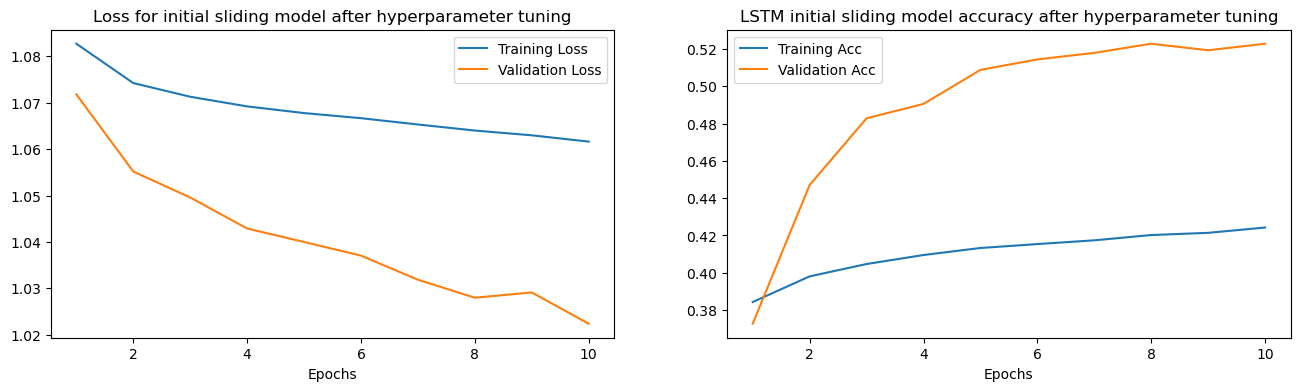

In [728]:
# Plotting the loss on the first subplot
hist_sl_init = model_LSTM_slide_initial_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_sl_init['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_sl_init['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for initial sliding model after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_sl_init['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_sl_init['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM initial sliding model accuracy after hyperparameter tuning')
plt.show()

In [729]:
print("Final training accuracy:", hist_sl_init['accuracy'][-1])
print("Final validation accuracy:", hist_sl_init['val_accuracy'][-1])

Final training accuracy: 0.4242246150970459
Final validation accuracy: 0.5228070020675659


The training and validation accuracies are comparable to before, which gives us at least some confidence that this model works reasonably well.

In [730]:
# Evaluating the model against X_test and Y_test
model_LSTM_slide_initial.evaluate(X_test_init, Y_test_init)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1472 - loss: 1.1384


[1.1323004961013794, 0.1621052622795105]

The test accuracy here looks extremely poor. However, analyzing the stock market on this date reveals that this particular day (12/20/24) was incredibly bullish, so our model may not have been able to capture that trend. We can analyze our confusion matrix to confirm this observation.

### Plotting a confusion matrix for the test predictions

In [732]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_slide_initial.predict(X_test_init)
Y_test_pred_perc = Y_test_pred.copy()
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test_init,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[ 14,   0,   9],
       [ 45,   0,  13],
       [329,   2,  63]])

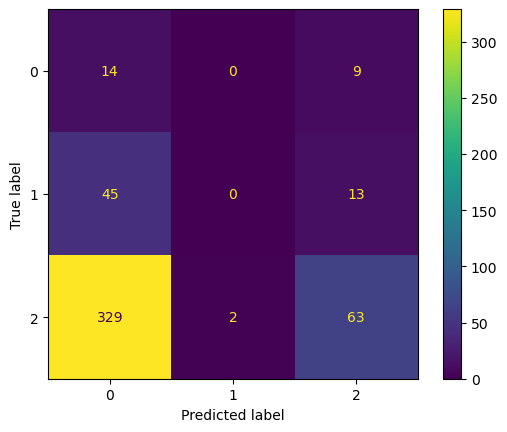

In [733]:
# Plotting the confusion matrix for the model
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test_init,
    y_pred=Y_test_pred,
    labels=None
)

As expected, because of how bullish this day was, most of the stocks were positive, and our model was unable to determine that. Even with a prediction threshold, it's unlikely that our model will be able to tell the difference.

### Further analyses with prediction threshold
We changed the prediction threshold from 0.4 to 0.9, but found that a threshold of 0.5 worked the best.

In [734]:
# Setting a prediction threshold of 0.5
pred_threshold = 0.5

# Getting the Y_test_pred_thresh
Y_test_pred_thresh = model_LSTM_slide_initial.predict(X_test_init)
Y_test_pred_thresh = np.where(Y_test_pred_thresh[:, 0] > pred_threshold, 0,
                                  np.where(Y_test_pred_thresh[:, 2] > pred_threshold, 2, 1))

# Getting the confusion matrix with the threshold
cf_thresh = confusion_matrix(
    Y_test_init,
    Y_test_pred_thresh
)

cf_thresh

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[  6,  12,   5],
       [ 18,  36,   4],
       [142, 239,  13]])

Once again, we see see that a prediction threshold doesn't matter much, as the market so heavily bullish on this day. Nevertheless, let's continue our sliding window (for the remaining 6 days in our dataset) and see what results we get.

## (Sliding Windows) Re-training the model as we slide the window for new data dates
We now slide the window over by one day, but keeping the 900 window size the same. We keep repeating until we run out of data (7 windows total including the initial window (we explain how we got this number below)), and we record our metrics in a metrics_dict that we have below.

In [735]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_data_smaller.shape[1]
num_features = X_data_smaller.shape[2]
n_classes = 3
LSTM_units = 128
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

In [755]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting the window size to slide over and other initial parameters
first_slide_day = 1
slide_amount = 1  # Amount to slide each window
window_size_slide = 900
train_window_slide = 896
val_window_slide = 3
test_window_slide = 1

# Getting a dictionary of different metrics
metrics_dict = {}

# Looping over the window range as we slide the window
# for start_day_num in range(first_slide_day, 3, slide_amount):
for start_day_num in range(first_slide_day, num_sequences_per_ticker - window_size_slide + 1, slide_amount):

    # Getting the windows for X and Y
    X_window = X_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]
    Y_window = Y_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]

    # Splitting data into train, val, and test sets
    X_train_sl, Y_train_sl, X_val_sl, Y_val_sl, X_test_sl, Y_test_sl = train_val_test_seq_split(
        X_window, Y_window, unique_tickers, train_window_slide, val_window_slide, test_window_slide)

    # Building the model from scratch
    model_LSTM_slide = build_LSTM_model_slide(seq_length=seq_length,
                                                  num_features=num_features,
                                                  n_classes=n_classes,
                                                  LSTM_units=LSTM_units,
                                                  learning_rate=learning_rate,
                                                  optimizer=optimizer,
                                                  metric=metric)
    
    # Fitting the model again for each slide
    model_LSTM_slide_fit = model_LSTM_slide.fit(
        x = X_train_sl,
        y = Y_train_sl,
        validation_data = [X_val_sl, Y_val_sl],
        epochs = num_epochs,
        batch_size = batch_size,
        verbose = 1)
    
    # Getting the final training and validation accuracies
    hist_sl = model_LSTM_slide_fit.history
    train_accuracy_sl = hist_sl['accuracy'][-1]
    val_accuracy_sl = hist_sl['val_accuracy'][-1]

    # Getting the test accuracy
    Y_test_sl_pred = model_LSTM_slide.predict(X_test_sl)  # Softmax predictions
    Y_test_sl_pred_no_thresh = np.argmax(Y_test_sl_pred, axis = 1)  # Argmax of predictions
    test_accuracy_sl = (Y_test_sl_pred_no_thresh == Y_test_sl).sum() / len(Y_test_sl)

    # Getting the no threshold confusion matrix using Y_test_sl and Y_test_sl_pred
    cf_no_thresh = confusion_matrix(
        Y_test_sl,
        Y_test_sl_pred_no_thresh)

    # Creating and appending metrics list to metrics_dict
    metrics_dict[start_day_num] = [train_accuracy_sl, val_accuracy_sl, test_accuracy_sl, cf_no_thresh]

    # Setting different prediction thresholds and getting the Y_test_sl_pred_thresh confusion matrix for each
    thresholds_list = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
    for threshold in thresholds_list:
        Y_test_sl_pred_thresh = np.where(Y_test_sl_pred[:, 0] > threshold, 0,
                                     np.where(Y_test_sl_pred[:, 2] > threshold, 2, 1))
        
        # Getting the confusion matrix for this threshold and appending it to the list in the dictionary
        cf_thresh = confusion_matrix(
            Y_test_sl,
            Y_test_sl_pred_thresh)
        metrics_dict[start_day_num].append(cf_thresh)
    

Epoch 1/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 162s 97ms/step - accuracy: 0.3766 - loss: 1.0894 - val_accuracy: 0.3340 - val_loss: 1.0577
Epoch 2/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 163s 98ms/step - accuracy: 0.3980 - loss: 1.0750 - val_accuracy: 0.3768 - val_loss: 1.0509
Epoch 3/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 164s 98ms/step - accuracy: 0.4049 - loss: 1.0713 - val_accuracy: 0.4119 - val_loss: 1.0435
Epoch 4/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 153s 92ms/step - accuracy: 0.4092 - loss: 1.0693 - val_accuracy: 0.4189 - val_loss: 1.0422
Epoch 5/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 154s 93ms/step - accuracy: 0.4123 - loss: 1.0678 - val_accuracy: 0.4316 - val_loss: 1.0398
Epoch 6/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 162s 97ms/step - accuracy: 0.4149 - loss: 1.0665 - val_accuracy: 0.4295 - val_loss: 1.0389
Epoch 7/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 159s 96ms/step - accuracy: 0.4168 - loss: 1.0655 - val_accuracy: 0.4309 - val_loss: 1.0383
Epoch 8/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 159s 96ms/step - accuracy: 

In [782]:
# Printing the full metrics_dict just to see it:
metrics_dict

{1: [0.42536184191703796,
  0.4343859553337097,
  0.5557894736842105,
  array([[  6,   8,  27],
         [  5, 116,  94],
         [  7,  70, 142]]),
  array([[  7,  19,  15],
         [  3, 153,  59],
         [ 10, 118,  91]]),
  array([[  2,  37,   2],
         [  2, 194,  19],
         [  2, 193,  24]]),
  array([[  0,  41,   0],
         [  0, 214,   1],
         [  0, 216,   3]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 217,   2]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 218,   1]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]]),
  array([[  0,  41,   0],
         [  0, 215,   0],
         [  0, 219,   0]])],
 2: [0.4266353249549866,
  0.4161403477191925,
  0.2905263157894737,
  array([[  6,   4,   4],
         [  4, 104,  16],
        

For clarity on the code below, our train day for the first result below starts on day 51 because:
1) This is the second time we're training this model (the previous, first experiment had a training day start of day 50), and
2) Our sequence length of 50 requires each series of data to include the current day and the previous 49 days (hence why our previous training day start was day 50).

The combined reasons above ultimately mean that we have to slide a 900-day window across 955 - 50 + 1 = 906 days, starting on day 50. Thus, our range of days is from day 50 to day 955, with 7 possible slides. The first window (in our previous experiment) started on Day 50 and went to Day 949 (Day 50 to Day 945 were the 896 (945 - 50 + 1 = 896) days of training data, Day 946 to Day 948 were the 3 validation days, and Day 949 was the test day). Similarly, the final, seventh window started on Day 56 and went to Day 955, which is indeed the last day in our data.

**Technically, the reason we have 955 days in the dataset is because we used the first 50 days for one of our features - SMA 50 (with previous day prices) - not to be confused with our sequence length of 50. Our original dataset came with 1,005 days of data; thus, our "starting day" of 50 is really a starting day of 100. However, for consistency purposes, we'll keep day 50 as our "true" start date.*

In [791]:
# Getting overall confusion matrix with 0.45 threshold
cf_overall_0_45 = np.zeros((3, 3))

# Printing the train, val, test accuracies for each window, along with the confusion matrices with a threshold of 0.45
for start_day, metrics in metrics_dict.items():

    # Getting actual days of when train/val/test data started and ended
    true_start_day = start_day + 50
    train_val_end = true_start_day + 898
    test_day = train_val_end + 1
    print(str(start_day) + ". Train/val from days " + str(true_start_day) + " to " + str(train_val_end) +
          "; test day on " + str(test_day) + ":")

    # Getting train, val, and test accuracies
    train_acc_rounded = round(metrics[0], 4)
    val_acc_rounded = round(metrics[1], 4)
    test_acc_rounded = round(metrics[2], 4)
    print(" - Train acc:", train_acc_rounded, "| val acc:", val_acc_rounded, "| test acc:", test_acc_rounded)

    # Getting appropriate confusion matrices for prediction threshold of 0.45
    print(" - Confusion matrix with threshold of 0.45:")
    print(metrics[4], '\n')

    # Adding the confusion matrix with a 0.45 threshold to the overall confusion matrix for this threshold
    cf_overall_0_45 += metrics[4]

1. Train/val from days 51 to 949; test day on 950:
 - Train acc: 0.4254 | val acc: 0.4344 | test acc: 0.5558
 - Confusion matrix with threshold of 0.45:
[[  7  19  15]
 [  3 153  59]
 [ 10 118  91]] 

2. Train/val from days 52 to 950; test day on 951:
 - Train acc: 0.4266 | val acc: 0.4161 | test acc: 0.2905
 - Confusion matrix with threshold of 0.45:
[[  5   9   0]
 [  2 120   2]
 [  1 321  15]] 

3. Train/val from days 53 to 951; test day on 952:
 - Train acc: 0.4265 | val acc: 0.3361 | test acc: 0.4547
 - Confusion matrix with threshold of 0.45:
[[  3  11   1]
 [  7 201   4]
 [ 17 225   6]] 

4. Train/val from days 54 to 952; test day on 953:
 - Train acc: 0.425 | val acc: 0.4393 | test acc: 0.6021
 - Confusion matrix with threshold of 0.45:
[[ 17  66   1]
 [ 21 298   2]
 [  6  60   4]] 

5. Train/val from days 55 to 953; test day on 954:
 - Train acc: 0.4257 | val acc: 0.433 | test acc: 0.4758
 - Confusion matrix with threshold of 0.45:
[[ 34 100   2]
 [ 52 222   6]
 [ 16  38   5]]

While we see decent results for some of the days, it's clear that our model does not generalize well at all. Specifically, almost all of the training data is the same across each window, which is reflected in the similar training accuracies for all days. However, the validation accuracies - and even more so the test accuracies - fluctuate wildly, with some days performing excruciatingly bad. We also chose to showcase the best threshold from the metrics (0.45), as higher thresholds produced far too few results, and lower thresholds were simply incorrect.

If we go on Google and take a look at the S&P500 for these particular days (12/23/24 - 12/31/24), we do see some rather large fluctuations (plus the holiday season probably didn't help). Thus, if we tested more data in periods with less volatility, we may have gotten better results (as huge fluctuations like this generally depend less on the stock performance, and more so on the overall economy). Furthermore, we might also want to add in seasonality to future models, as they may change how markets (and individual stocks) respond to both external and momentum pressures.

For some consolation, at least with a prediction threshold of 0.45, our precision for Class 2 (buying long) seems to consistently be pretty decent. In all cases, we more often predict the true class (Class 2) than the opposite class (Class 0), and this was the case on the first day as well (in the previous experiment). Conversely, for Class 0 (selling short), we predicted the opposite class (now Class 2) more often than the true class (now Class 0) twice out of the 6 days, which is clearly not as good. Nevertheless, even with the immense variation in our model predictions, getting any sort of result is better than getting no result whatsoever.

Lastly, we can actually see the results of our overall confusion matrix with a prediction threshold of 0.45. Again, this means that unless the softmax prediction for Class 0 or Class 2 is greater than or equal to 0.45, it will default to a prediction of Class 1.

***Note: we made a typo over the last two blocks of code. Instead of a 0.45 threshold, we accidentally used a prediction threshold of 0.40 (metrics[4]). Due to the amount of time we have left to work on this project, we'll forgo re-running this model because of how long it will take. However, the analysis does not change, and in fact a threshold of 0.45 would have produced even better results than a threshold of 0.40.**

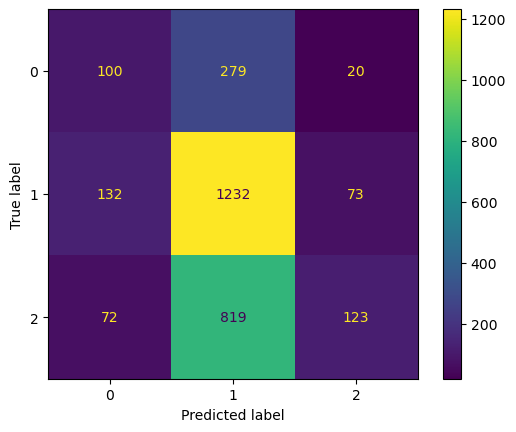

In [799]:
# Getting the combined confusion matrix for a prediction threshold of 0.45
disp = ConfusionMatrixDisplay(cf_overall_0_45.astype(int))
disp.plot()
plt.show()

And once again, we see that our Class 2 predictions are quite good, and our Class 0 predictions are not so much. To be even more thorough, we can also obtain our precision and recall metrics from this combined matrix, though we will save that for when we evaluate the new data from 2025.

Lastly, we'll eventually need to analyze exactly how much we would have made or lost had we gone in based on our model predictions, as these numbers only tell us whether or not the stock ended up closing higher or lower than the Open (or stayed roughly the same) for that particular day. Essentially, this data does not tell us how large the difference between the two prices are, and we'll need to do more analysis to figure that out.

# Evaluating Final Model Performance with the New Test Set from 2025
As we can see from above, evaluating model performance with this sliding model is somewhat difficult, as we need to retrain the model every single time, along with combining the accuracy confusion matrices. Therefore we will save our models in one place, so we only need to run them once (and then evaluate the metrics that we need from them).

## Getting new data from 2025
Before we re-run the models, we will need to download and clean the new data in 2025. However, we will do this in a separate notebook, and we'll upload the cleaned results back into this one.

### Loading in data

In [33]:
# Loading in stock data as of 3/26/25
data = pd.read_csv("../SP500_updated_data_2025_03_26.csv", index_col='Date', parse_dates=True)

# Converting Date_col to datetime format
data['Date_col'] = pd.to_datetime(data['Date_col'])

### Performing the same feature engineering as above

In [34]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875044,116.995403,114.092199,115.582771,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426878,117.219459,115.027439,116.527756,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,True,2
2021-01-07,2021-01-07,A,121.126114,124.194943,120.911782,122.908958,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230478,124.350845,122.606971,123.785789,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-20,2025-03-20,ZTS,163.830002,164.139999,162.250000,163.160004,2026600.0,1058.0,-0.669998,-0.408959,False,1
2025-03-21,2025-03-21,ZTS,162.880005,163.039993,160.910004,163.029999,2886900.0,1059.0,0.149994,0.092089,True,1
2025-03-24,2025-03-24,ZTS,162.270004,165.479996,161.699997,163.169998,1817400.0,1060.0,0.899994,0.554627,True,2


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [35]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875044,116.995403,114.092199,115.582771,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426878,117.219459,115.027439,116.527756,2344000.0,2.0,1.100878,0.953745,...,2,-0.386767,0.191508,0.819723,0.817582,115.875044,116.995403,114.092199,115.582771,2030700.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,2,0.177235,2.958765,0.118564,2.742235,115.426878,117.219459,115.027439,116.527756,2344000.0
2021-01-07,2021-01-07,A,121.126114,124.194943,120.911782,122.908958,1775900.0,4.0,1.782844,1.471891,...,2,4.751873,2.906042,4.991118,2.660919,115.631454,120.687707,115.163820,119.723221,2428500.0
2021-01-08,2021-01-08,A,123.230478,124.350845,122.606971,123.785789,1577200.0,5.0,0.555311,0.450628,...,1,1.737333,0.125530,1.402004,0.713399,121.126114,124.194943,120.911782,122.908958,1775900.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [36]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097539,124.506722,123.035631,124.068314,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419030,125.597848,124.078050,124.808723,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477465,125.461440,123.162255,123.727310,1612100.0,13.0,-0.750154,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805266,124.506713,123.045367,123.074593,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425324,124.194968,121.223560,122.246506,1365400.0,15.0,-1.178819,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265979,122.704380,120.677985,120.726692,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934116,119.830407,115.066418,115.738640,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933484,119.508910,115.719152,118.427513,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001683,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086527,118.554161,116.206261,117.073326,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [37]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875044,116.995403,114.092199,115.582771,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426878,117.219459,115.027439,116.527756,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126114,124.194943,120.911782,122.908958,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230478,124.350845,122.606971,123.785789,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191490,126.007016,122.977165,124.847679,1746800.0,6.0,1.656189,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023044,125.081496,122.947928,123.698090,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175459,124.750259,123.474012,123.707832,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990370,124.886668,122.577738,122.782326,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data['GICS Sector'] = data['GICS Sector'].fillna('Other')

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875044,116.995403,114.092199,115.582771,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426878,117.219459,115.027439,116.527756,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126114,124.194943,120.911782,122.908958,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230478,124.350845,122.606971,123.785789,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


### Selecting base features and normalizing data
Of the features we created, we select only the ones that we intend on using.

In [44]:
data.columns

Index(['Date_col', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rank',
       'Close_Open_Diff', 'Close_Open_Diff_Perc', 'Close_Open_Diff_Binary',
       'Close_Open_Diff_Ternary', 'Growth Rate_Open', 'Growth Rate_High',
       'Growth Rate_Low', 'Growth Rate_Close', 'PDO', 'PDH', 'PDL', 'PDC',
       'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Volume_14D', 'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_14', 'SMA_50',
       'SMA_200', 'EMA_9', 'EMA_20', 'SMA_prev_14', 'SMA_prev_50',
       'SMA_prev_200', 'EMA_prev_9', 'EMA_prev_20', 'RSI_14', 'RSI_prev_14',
       'ATR_14', 'NATR_14', 'GICS Sector'],
      dtype='object')

In [45]:
# Getting a copy of the data to work with so we don't ruin original
data_small = data.copy()

# Removing BIIB ticker in general (since it's missing data for one of the trading days)
data_small = data_small[data_small['Ticker'] != 'BIIB']

# If rank is less than or equal to the number of NA_days, drop the row (since there will be NaN data)
NA_days = 50  # Choosing 50 for SMA_prev_50
data_small = data_small[data_small['rank'] > NA_days]

# Only keeping certain columns
data_small_columns_keep = ['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold',
    'Daily_Range_Gap_Up', 'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary', 'Avg_Vol_Prev_14D', 'Vol_Change',
    'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14', 'GICS Sector', 'Close_Open_Diff_Perc',
    'Close_Open_Diff_Ternary']

data_small = data_small[data_small_columns_keep]

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,480700,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,4.807000e+05,480700.000000,480700.000000,480700.000000,4.807000e+05,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000
mean,2023-03-20 00:18:29.881422592,169.786583,169.730370,171.626647,167.800874,169.735125,5.908124e+06,0.000308,0.001023,-0.000996,5.907015e+06,0.026456,169.365201,168.217688,169.506664,169.178752,51.649001,2.365740,0.007135,1.012272
min,2021-03-17 00:00:00,1.010000,1.010000,1.040000,0.780000,0.980000,6.300000e+03,-0.388039,0.000000,-0.386389,1.150000e+04,-0.915551,1.055000,1.203000,1.059442,1.095938,3.203537,0.212823,-50.071084,0.000000
25%,2022-03-16 18:00:00,51.600435,51.586836,52.165556,50.980187,51.575057,1.008100e+06,-0.003835,0.000000,0.000000,1.105098e+06,-0.261395,51.514275,51.298804,51.537871,51.519669,42.872374,1.756339,-0.846850,0.000000
50%,2023-03-20 12:00:00,98.613571,98.600685,99.760002,97.398547,98.596329,2.057600e+06,0.000411,0.000000,0.000000,2.167693e+06,-0.081298,98.530269,98.096348,98.575463,98.510715,51.637393,2.168713,0.027435,1.000000
75%,2024-03-21 06:00:00,189.396419,189.331653,191.392298,187.168375,189.304024,4.685325e+06,0.004649,0.000000,0.000000,4.789305e+06,0.165223,189.139499,188.168872,189.279976,189.067715,60.433688,2.741198,0.875400,2.000000
max,2025-03-26 00:00:00,9914.169922,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,0.536680,0.391608,0.000000,7.066849e+08,25.587868,9677.040737,9442.719980,9744.845871,9637.574378,96.316095,18.195811,32.653064,2.000000
std,NaN,362.082798,361.889941,365.963457,357.912348,361.915044,2.378310e+07,0.011206,0.004900,0.005417,2.277575e+07,0.536602,360.569705,356.606362,361.035642,359.808006,12.200676,0.905704,1.617508,0.829392


In [51]:
# Getting some percent changes for the PDC compared to PDO for the first 5 values of data_small
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']
# These values will be a good litmus test to confirm that our normalization kept our percent differences between price values

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [52]:
# Doing the same, but for volume
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [53]:
# Defining a function to normalize the prices/volume to the max (*2) of every ticker
def normalize_to_max_per_ticker(df, col_list):
    df_normalized = df.copy()

    # Grouping by Ticker and getting the max values for either price or volume by ticker
    max_vals = df_normalized.groupby('Ticker')[col_list].transform('max').max(axis=1)

    # Applying normalization to entire df by dividing by max values for each ticker and then multiplying by 2
    df_normalized[col_list] = df_normalized[col_list].div(max_vals, axis=0) * 2

    return df_normalized

# Note: We normalize to the maximum (instead of using MinMax) of each ticker in order to preserve the same % changes as the unnormalized
# value. In our case, our normalized maximum will be 2, so our values will range from (down to) 0 to 2

**Note: We want to point out that we're technically normalizing against our test dataset, which we typically shouldn't do as it exposes our test data. However, the only alternative to doing so would be to recreate our data every single time we run the model for a new day, which is extremely time-consuming (along with compute-heavy), as we need to regenerate all the sequence data as well from this dataset. While we could make the effort to ensure that that's the case, it likely won't change very much for the model, and we do not believe the juice is worth the squeeze. We do recognize that we're potentially sacrificing test accuracy in the end, but we're willing to make that tradeoff if it means we can get some sort of result before the end of the project.**

In [54]:
# Normalizing the following columns to the global maximum prices (by percent compared to max price) for each ticker 
# ^e.g., if OHLC for a day is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively for that day
price_cols_to_norm = ['Open', 'PDO', 'PDH', 'PDL', 'PDC', 'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20']
data_small = normalize_to_max_per_ticker(data_small, price_cols_to_norm)

# Normalizing volumes for all dates to the global maximum volume (by percent compared to max volume) for each ticker
volume_cols_to_norm = ['PDV', 'Avg_Vol_Prev_14D']
data_small = normalize_to_max_per_ticker(data_small, volume_cols_to_norm)

# Normalizing the following columns as percent (currently these are decimal changes) (except Vol_Change)
cols_to_perc = ['Gap_from_PDC', 'Daily_Range_Gap_Up', 'Daily_Range_Gap_Down']
data_small.loc[:, cols_to_perc] = data_small.loc[:, cols_to_perc] * 100

# Normalizing RSI to be between 0 and 1
data_small.loc[:, ['RSI_prev_14']] = data_small.loc[:, ['RSI_prev_14']] / 100

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,480700,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000,480700.000000
mean,2023-03-20 00:18:29.881422592,1.340058,1.339800,1.354778,1.324402,1.339678,0.323808,0.030844,0.102289,-0.099614,0.323512,0.026456,1.337895,1.331686,1.338579,1.337067,0.516490,2.365740,0.007135,1.012272
min,2021-03-17 00:00:00,0.053784,0.053784,0.056452,0.052552,0.053707,0.008487,-38.803893,0.000000,-38.638898,0.013925,-0.915551,0.063100,0.070444,0.060571,0.069261,0.032035,0.212823,-50.071084,0.000000
25%,2022-03-16 18:00:00,1.103336,1.103067,1.116816,1.089255,1.103219,0.173739,-0.383543,0.000000,0.000000,0.196649,-0.261395,1.102831,1.099646,1.103434,1.103096,0.428724,1.756339,-0.846850,0.000000
50%,2023-03-20 12:00:00,1.379664,1.379330,1.394735,1.363549,1.379303,0.279672,0.041054,0.000000,0.000000,0.305594,-0.081298,1.377908,1.372284,1.378740,1.377662,0.516374,2.168713,0.027435,1.000000
75%,2024-03-21 06:00:00,1.609027,1.608649,1.625405,1.591015,1.608298,0.416471,0.464868,0.000000,0.000000,0.428861,0.165223,1.606229,1.598152,1.606922,1.604941,0.604337,2.741198,0.875400,2.000000
max,2025-03-26 00:00:00,2.000000,2.000000,2.000000,1.987241,2.000000,2.000000,53.667959,39.160845,0.000000,1.396082,25.587868,1.993995,2.000000,1.994547,2.000000,0.963161,18.195811,32.653064,2.000000
std,NaN,0.349927,0.349845,0.351976,0.347278,0.349661,0.220779,1.120609,0.489963,0.541727,0.168276,0.536602,0.347222,0.341143,0.347480,0.344840,0.122007,0.905704,1.617508,0.829392


In [55]:
# Double checking data_small shows us that we do indeed keep % differences between price features on the same day even after normalization
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [56]:
# And we see that we also keep % differences between the two volume features on the same day after normalization
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [57]:
# Ordering by date, and then by ticker to get the right splits for train/val/test
data_small = data_small.sort_values(by=['Date_col', 'Ticker'])

### Creating dummy variables for GICS Sector

In [59]:
# Getting a copy of data_small called data_smaller
data_smaller = data_small.copy()

In [60]:
# Getting dummy variables for GICS Sector
sector_dummy = pd.get_dummies(
    data_smaller['GICS Sector'],
    drop_first = False
)
print("Number of data_smaller dummy variables:", data_smaller['GICS Sector'].nunique())
print("Shape of data_smaller dummy variable for GICS Sector:",
      sector_dummy.shape, '\n')

# Adding the dummy variables to data_smaller
data_smaller = pd.concat(
    [data_smaller, sector_dummy],
    axis=1
)

Number of data_smaller dummy variables: 12
Shape of data_smaller dummy variable for GICS Sector: (480700, 12) 



In [61]:
# Checking to make sure dummies were created correctly
data_smaller.head(3)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391717,1.359954,1.366062,0.274100,-0.536590,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-17,2021-03-17,AAL,1.848984,1.924875,1.935608,1.863549,1.875814,0.577977,-1.430317,False,...,False,False,False,False,False,False,False,True,False,False
2021-03-17,2021-03-17,AAP,1.455625,1.470280,1.472615,1.427039,1.442258,0.090444,0.926808,False,...,False,False,False,False,False,False,False,True,False,False


In [62]:
# Removing GICS Sector since we've converted it to one-hot encoding
data_smaller = data_smaller.drop("GICS Sector", axis = 1)

print("Shape of data_smaller after removing original GICS Sector feature:",
      data_smaller.shape)

Shape of data_smaller after removing original GICS Sector feature: (480700, 36)


## Generating X continuous series sequences and Y continuous labels for LSTM model
Once again, we use the correct generation method as we did above.

In [63]:
# Creating sequences for LSTM model
seq_length = 50
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [64]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (457425, 50, 32)
Shape of Y_data_smaller: (457425,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 1012
Chosen sequence length: 50
Number of sequences assuming the above seq_length: 963
Total number of data sequences expected: 457425
Total number of data sequences achieved: 457425


## Training and evaluating the final LSTM model (896/3/1 train/val/test split) for each sliding window in the new data
We will perform the same training and test loop as we did previously, keeping our window size of 900. This time, however, instead of having just 7 windows, we have 57 more days of data, giving us 64 windows total. **For better reproducibility, we'll also save each model in a separate folder so we can repeat this process if necessary.** For example, after we've trained all 64 models, we can simply load each one up to evaluate our test data at a later date if we wish.

In [70]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_data_smaller.shape[1]
num_features = X_data_smaller.shape[2]
n_classes = 3
LSTM_units = 128
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

In [76]:
# Setting seed for consistent re-runs
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting the window size to slide over and other initial parameters
num_sequences_per_ticker = unique_dates - seq_length + 1
first_slide_day = 0
slide_amount = 1
window_size_slide = 900
train_window_slide = 896
val_window_slide = 3
test_window_slide = 1

# Getting a dictionary of different metrics
metrics_dict = {}

# Looping over the window range as we slide the window
for start_day_num in range(first_slide_day, num_sequences_per_ticker - window_size_slide + 1, slide_amount):

    # Getting the windows for X and Y
    X_window = X_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]
    Y_window = Y_data_smaller[(unique_tickers * start_day_num):(unique_tickers * (start_day_num + window_size_slide))]

    # Splitting data into train, val, and test sets
    X_train_sl, Y_train_sl, X_val_sl, Y_val_sl, X_test_sl, Y_test_sl = train_val_test_seq_split(
        X_window, Y_window, unique_tickers, train_window_slide, val_window_slide, test_window_slide)

    # Building the model from scratch
    model_LSTM_slide = build_LSTM_model_slide(seq_length=seq_length,
                                                  num_features=num_features,
                                                  n_classes=n_classes,
                                                  LSTM_units=LSTM_units,
                                                  learning_rate=learning_rate,
                                                  optimizer=optimizer,
                                                  metric=metric)
    
    # Fitting the model again for each slide
    model_LSTM_slide_fit = model_LSTM_slide.fit(
        x = X_train_sl,
        y = Y_train_sl,
        validation_data = [X_val_sl, Y_val_sl],
        epochs = num_epochs,
        batch_size = batch_size,
        verbose = 1)

    # UPDATED: SAVING THE MODEL FOR EACH RUN
    model_save_path = './02_Saved_Models/model_LSTM_slide_2025_03_27_start_day_' + str(start_day_num) + '.keras'
    model_LSTM_slide.save(model_save_path)
    
    # Getting the final training and validation accuracies
    hist_sl = model_LSTM_slide_fit.history
    train_accuracy_sl = hist_sl['accuracy'][-1]
    val_accuracy_sl = hist_sl['val_accuracy'][-1]

    # Getting the test accuracy
    Y_test_sl_pred = model_LSTM_slide.predict(X_test_sl)  # Softmax predictions
    Y_test_sl_pred_no_thresh = np.argmax(Y_test_sl_pred, axis = 1)  # Argmax of predictions
    test_accuracy_sl = (Y_test_sl_pred_no_thresh == Y_test_sl).sum() / len(Y_test_sl)

    # Getting the no threshold confusion matrix using Y_test_sl and Y_test_sl_pred
    cf_no_thresh = confusion_matrix(
        Y_test_sl,
        Y_test_sl_pred_no_thresh)

    # Creating and appending metrics list to metrics_dict
    metrics_dict[start_day_num] = [train_accuracy_sl, val_accuracy_sl, test_accuracy_sl, cf_no_thresh]

    # Setting different prediction thresholds and getting the Y_test_sl_pred_thresh confusion matrix for each
    thresholds_list = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
    for threshold in thresholds_list:
        Y_test_sl_pred_thresh = np.where(Y_test_sl_pred[:, 0] > threshold, 0,
                                     np.where(Y_test_sl_pred[:, 2] > threshold, 2, 1))
        
        # Getting the confusion matrix for this threshold and appending it to the list in the dictionary
        cf_thresh = confusion_matrix(
            Y_test_sl,
            Y_test_sl_pred_thresh)
        metrics_dict[start_day_num].append(cf_thresh)
    

Epoch 1/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 137s 82ms/step - accuracy: 0.3727 - loss: 1.0916 - val_accuracy: 0.4070 - val_loss: 1.0684
Epoch 2/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 137s 83ms/step - accuracy: 0.3982 - loss: 1.0753 - val_accuracy: 0.4737 - val_loss: 1.0537
Epoch 3/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 139s 83ms/step - accuracy: 0.4042 - loss: 1.0717 - val_accuracy: 0.4905 - val_loss: 1.0456
Epoch 4/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 127s 76ms/step - accuracy: 0.4091 - loss: 1.0698 - val_accuracy: 0.5039 - val_loss: 1.0422
Epoch 5/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 128s 77ms/step - accuracy: 0.4133 - loss: 1.0683 - val_accuracy: 0.5179 - val_loss: 1.0386
Epoch 6/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 132s 79ms/step - accuracy: 0.4151 - loss: 1.0668 - val_accuracy: 0.5214 - val_loss: 1.0343
Epoch 7/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 136s 82ms/step - accuracy: 0.4176 - loss: 1.0653 - val_accuracy: 0.5179 - val_loss: 1.0302
Epoch 8/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 133s 80ms/step - accuracy: 

In [212]:
# Printing the full metrics_dict just to see it
metrics_dict

{0: [0.4249013066291809,
  0.535438597202301,
  0.14526315789473684,
  array([[ 17,   0,   6],
         [ 52,   0,   7],
         [340,   1,  52]]),
  array([[ 19,   0,   4],
         [ 54,   1,   4],
         [352,  16,  25]]),
  array([[ 12,   5,   6],
         [ 40,  14,   5],
         [261, 102,  30]]),
  array([[  8,  11,   4],
         [ 19,  38,   2],
         [152, 230,  11]]),
  array([[  3,  17,   3],
         [ 15,  42,   2],
         [ 70, 317,   6]]),
  array([[  1,  22,   0],
         [  6,  53,   0],
         [ 23, 365,   5]]),
  array([[  1,  22,   0],
         [  1,  58,   0],
         [  0, 390,   3]]),
  array([[  0,  23,   0],
         [  0,  59,   0],
         [  0, 391,   2]]),
  array([[  0,  23,   0],
         [  0,  59,   0],
         [  0, 393,   0]]),
  array([[  0,  23,   0],
         [  0,  59,   0],
         [  0, 393,   0]])],
 1: [0.42414942383766174,
  0.45754384994506836,
  0.5389473684210526,
  array([[ 11,   9,  20],
         [ 11, 104, 101],
       

It took roughly ~30 hours to run all the models above, and this was us re-training and re-running every single model for all the days up till March 26, 2025. Just from a few of the initial test accuracies, our models seem to have done quite poorly for many of the dates in 2025. However, this can likely be explained by the immense variation in what can happen on a day-to-day basis. To view our results better, we can plot the confusion matrices for one prediction threshold, along with finding the respective training, validation, and test accuracies.

## Plotting a confusion matrix for the combined test predictions and finding overall precision
As mentioned in our model testing section, we mistakenly used a prediction threshold of just 0.4 instead of 0.45, which meant that the threshold to be classified as Class 0 or Class 2 was lower than it should have been. However, the results were similar even with a threshold of 0.45, as the model itself is the same.

After running and testing our model more, we ultimately chose to increase the prediction threshold to **0.5**, as this provides a good blend of increased precision (since the requirement for predicting classes 0 or 2 is more strict) and enough predictions for us to go in (i.e., if our prediction threshold were too high, like 0.9, we'll have no predictions for classes 0 or 2 on most of the days).

This first confusion matrix combines every single confusion matrix (with a 0.5 prediction threshold) to find the overall precision of our model.

In [221]:
# Initializing overall confusion matrix with 0.5 threshold
cf_overall_0_5 = np.zeros((3, 3))

# Printing the train, val, test accuracies for each window, along with the confusion matrices with a threshold of 0.5
for start_day, metrics in metrics_dict.items():

    # Getting actual days of when train/val/test data started and ended
    true_start_day = start_day + 50
    train_val_end = true_start_day + 898
    test_day = train_val_end + 1
    print(str(start_day) + ". Train/val from days " + str(true_start_day) + " to " + str(train_val_end) +
          "; test day on " + str(test_day) + ":")

    # Getting train, val, and test accuracies
    train_acc_rounded = round(metrics[0], 4)
    val_acc_rounded = round(metrics[1], 4)
    test_acc_rounded = round(metrics[2], 4)
    print(" - Train acc:", train_acc_rounded, "| val acc:", val_acc_rounded, "| test acc:", test_acc_rounded)

    # Getting appropriate confusion matrices for prediction threshold of 0.5
    print(" - Confusion matrix with threshold of 0.5:")
    print(metrics[6], '\n')

    # Adding the confusion matrix with a 0.5 threshold to the overall confusion matrix for this threshold
    cf_overall_0_5 += metrics[6]

0. Train/val from days 50 to 948; test day on 949:
 - Train acc: 0.4249 | val acc: 0.5354 | test acc: 0.1453
 - Confusion matrix with threshold of 0.5:
[[  8  11   4]
 [ 19  38   2]
 [152 230  11]] 

1. Train/val from days 51 to 949; test day on 950:
 - Train acc: 0.4241 | val acc: 0.4575 | test acc: 0.5389
 - Confusion matrix with threshold of 0.5:
[[  1  39   0]
 [  1 213   2]
 [  0 217   2]] 

2. Train/val from days 52 to 950; test day on 951:
 - Train acc: 0.4257 | val acc: 0.4084 | test acc: 0.2926
 - Confusion matrix with threshold of 0.5:
[[  1  13   0]
 [  0 125   0]
 [  0 336   0]] 

3. Train/val from days 53 to 951; test day on 952:
 - Train acc: 0.4267 | val acc: 0.3411 | test acc: 0.5032
 - Confusion matrix with threshold of 0.5:
[[  0  15   0]
 [  2 211   0]
 [  0 247   0]] 

4. Train/val from days 54 to 952; test day on 953:
 - Train acc: 0.4259 | val acc: 0.4309 | test acc: 0.6084
 - Confusion matrix with threshold of 0.5:
[[  1  83   0]
 [  4 318   0]
 [  1  68   0]] 



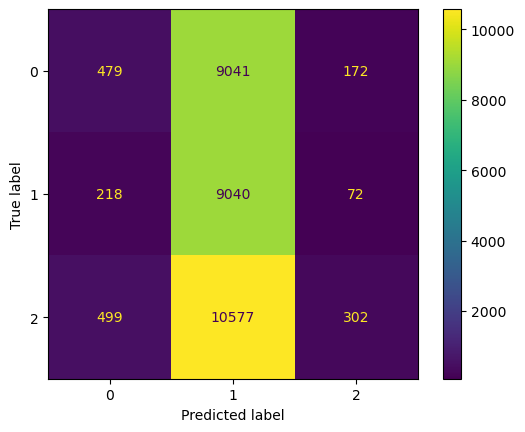

In [222]:
# Getting the combined confusion matrix for a prediction threshold of 0.5
disp = ConfusionMatrixDisplay(cf_overall_0_5.astype(int))
disp.plot()
plt.show()

Once again, what matters for us is precision (TP / (TP + FP)), as we care about how "right" we are when we predict a certain class. For example, if we predict a stock to close higher than its Open for a particular day, we want to know how "precise" that measurement is. Additionally, for our purposes, if our model ever predicts a class of 1 (meaning that the Close price is not expected to be significantly different from the Open price), we would be better off not going in at all. Therefore, it would not be unreasonable to only focus on the predicted labels of 0 and 2 and understand what they mean:

In [224]:
# Getting more granular precision metrics for classes 0 and 2
sum_pred_0 = np.sum(cf_overall_0_5, axis=0)[0]
sum_pred_2 = np.sum(cf_overall_0_5, axis=0)[2]
pred_0_true_0 = cf_overall_0_5[0, 0] / sum_pred_0
pred_0_true_1 = cf_overall_0_5[1, 0] / sum_pred_0
pred_0_true_2 = cf_overall_0_5[2, 0] / sum_pred_0
pred_2_true_0 = cf_overall_0_5[0, 2] / sum_pred_2
pred_2_true_1 = cf_overall_0_5[1, 2] / sum_pred_2
pred_2_true_2 = cf_overall_0_5[2, 2] / sum_pred_2

print("When predicting Class 0 (sell short):")
print(" - True Positive for Class 0 (Precision):", round(pred_0_true_0, 4))
print(" - False Positive for Class 1:", round(pred_0_true_1, 4))
print(" - False Positive for Class 2:", round(pred_0_true_2, 4), '\n')

print("When predicting Class 2 (buy long):")
print(" - False Positive for Class 0:", round(pred_2_true_0, 4))
print(" - False Positive for Class 1:", round(pred_2_true_1, 4))
print(" - True Positive for Class 2 (Precision):", round(pred_2_true_2, 4))

When predicting Class 0 (sell short):
 - True Positive for Class 0 (Precision): 0.4005
 - False Positive for Class 1: 0.1823
 - False Positive for Class 2: 0.4172 

When predicting Class 2 (buy long):
 - False Positive for Class 0: 0.315
 - False Positive for Class 1: 0.1319
 - True Positive for Class 2 (Precision): 0.5531


Once again, we confirm that our model did a pretty poor job predicting whether a stock would close higher or lower than its Open. While it performed better on the long side, we still got many of our predictions wrong. However, instead of getting a combined confusion matrix, we can instead try to analyze our average accuracy and precision metrics for the predicted classes of 0 and 2 for each test day.

## Analyzing average precision metrics for Class 0 and Class 2
Unlike in the previous experiment, where we combined our predictions, we'll instead calculate our average precisions across all 64 days. This makes more sense in the real-world, as whether you have a 4:2 ratio of correct:incorrect predictions or a 40:20 ratio of correct:incorrect predictions, you can only trade so many stocks in a single day. Therefore, we care more about the percent of accurate predictions for each day rather than the absolute numbers.

As explained previously, we primarily care about Class 0 and Class 2, as those are our indicators for going in short or long. Therefore, when calculating precision, we'll focus mainly on these two classes and not Class 1. Furthermore, we can also analyze our false positive rate for the opposite class (i.e., not the neutral Class 1), which will give us a measure of how often we win compared to how often we lose.

In [228]:
# Initializing dictionary of lists of precisions for Class 0 and Class 2, along with a dictionary of false positives
# *One dictionary of false positives is for the opposite class (Class 0 vs Class 2 and vice versa), and one is for the neutral Class 1
class_0_2_prec = {'Class 0 Precisions': [], 'Class 2 Precisions': []}
opposite_class_fp = {'Class 0 Opposite FP': [], 'Class 2 Opposite FP': []}
neutral_class_fp = {'Class 0 Neutral FP': [], 'Class 2 Neutral FP': []}

# Getting the precision scores and false positive rates for Class 0 and Class 2 for every test day (with a prediction threshold of 0.5)
for start_day, metrics in metrics_dict.items():

    # Getting more granular precision metrics for classes 0 and 2
    cf_indiv = metrics[6]
    sum_pred_0 = np.sum(cf_indiv, axis=0)[0]
    sum_pred_2 = np.sum(cf_indiv, axis=0)[2]
    pred_0_true_0 = cf_indiv[0, 0] / sum_pred_0
    pred_0_true_1 = cf_indiv[1, 0] / sum_pred_0
    pred_0_true_2 = cf_indiv[2, 0] / sum_pred_0
    pred_2_true_0 = cf_indiv[0, 2] / sum_pred_2
    pred_2_true_1 = cf_indiv[1, 2] / sum_pred_2
    pred_2_true_2 = cf_indiv[2, 2] / sum_pred_2

    # Adding each precision to their respective lists in the precision dictionary
    class_0_2_prec['Class 0 Precisions'].append(pred_0_true_0)
    class_0_2_prec['Class 2 Precisions'].append(pred_2_true_2)
    opposite_class_fp['Class 0 Opposite FP'].append(pred_0_true_2)
    opposite_class_fp['Class 2 Opposite FP'].append(pred_2_true_0)
    neutral_class_fp['Class 0 Neutral FP'].append(pred_0_true_1)
    neutral_class_fp['Class 2 Neutral FP'].append(pred_2_true_1)

warnings.filterwarnings('ignore')

In [641]:
# Showing an example of the True Positives (precision scores for class 0 or 2) for each day
pd.DataFrame(class_0_2_prec)

,Class 0 Precisions,Class 2 Precisions
0,0.044693,0.647059
1,0.500000,0.500000
2,1.000000,NaN
3,0.000000,NaN
4,0.166667,NaN
...,...,...
59,0.000000,1.000000
60,0.204082,0.750000
61,0.000000,0.750000
62,0.500000,0.000000


*Note: There are times when we get 0 predictions for Class 0 or Class 2, which happens when none of the softmax predictions for those classes are above our prediction threshold of 0.5. What this means in practice is that our model doesn't think we should trade any stock on that day in that direction. If there are no predictions for **both** Class 0 and Class 2, then our model predicts that most of the trades will be roughly neutral, meaning that we shouldn't go in at all that day.*

In [229]:
# Showing the average precisions and false positives for Class 0 and Class 2
print("Average precisions across 64 test days for Class 0 and Class 2:")
print(pd.DataFrame(class_0_2_prec).mean(), '\n')
print("Average false positive rate for the opposite class across 64 test days for Class 0 and Class 2:")
print(pd.DataFrame(opposite_class_fp).mean(), '\n')
print("Average false positive rate for the neutral Class 1 across 64 test days for Class 0 and Class 2:")
print(pd.DataFrame(neutral_class_fp).mean())

Average precisions across 64 test days for Class 0 and Class 2:
Class 0 Precisions    0.529621
Class 2 Precisions    0.547396
dtype: float64 

Average false positive rate for the opposite class across 64 test days for Class 0 and Class 2:
Class 0 Opposite FP    0.275412
Class 2 Opposite FP    0.311823
dtype: float64 

Average false positive rate for the neutral Class 1 across 64 test days for Class 0 and Class 2:
Class 0 Neutral FP    0.194967
Class 2 Neutral FP    0.140781
dtype: float64


When looking at the results in this manner, we see that our model does seem to perform better than before. Specifically, our precision scores for the true positives are higher than the false positive rates for both classes. If we want to translate this into real-world trading: if we put money in at 9:30am ET on any particular day for any stock in the S&P500 and we take our money out at 4:00pm ET:
 - If the model predicts that we should sell short (Class 0):
   - We have a ~53% chance to earn money, ~19% chance to break even, and ~28% chance to lose money.
 - If the model predicts that we should buy long (Class 2):
   - We have a ~55% chance to earn money, ~14% chance to break even, and ~31% chance to lose money.

Before we discuss what these numbers mean, we can first set a baseline for us to compare this to. 

## Creating different baselines for comparison
In most cases, we should fully develop our baselines much earlier (before we even developed the models). However, due to the highly-changing nature of our project and what we wanted to predict (i.e., single test days with the sliding windows), our original baselines became irrelevant very early on. Furthermore, because we re-train our model for every sliding window with new training data, we would theoretically need a new baseline for every single run. For example, if we had a majority class baseline, that might change depending on what dates we choose for our training data.

Therefore, to keep things simple and consistent for understanding, we'll develop our baselines using the very first training window of our data. We recognize this is not entirely accurate as we slide our windows across, but the change should not be too dramatic (especially for a majority class baseline).

### 1. Majority class baseline
Our first baseline is a majority class baseline, where we see which class in our first training window has the most observations and always predict that class.

In [114]:
# We get our X_train_baseline and Y_train_baseline from the first 896 days of data (since that's our training window size)
train_window_slide = 896
X_train_baseline = X_data_smaller[:(unique_tickers * train_window_slide)]
Y_train_baseline = Y_data_smaller[:(unique_tickers * train_window_slide)]

baseline_class_counts = pd.DataFrame(Y_train_baseline).value_counts()
baseline_class_counts = pd.concat([baseline_class_counts, baseline_class_counts/len(Y_train_baseline)], axis=1)
baseline_col_names = ['Number of Predictions', 'Percent of Total']
baseline_class_counts.columns = baseline_col_names
baseline_class_counts.index.names = ['Class Prediction']

baseline_class_counts

,Number of Predictions,Percent of Total
Class Prediction,,
2,148293,0.348433
0,144430,0.339356
1,132877,0.312211


We can see pretty clearly from this baseline that if we always predict the majority Class 2 (or that the Close price will be higher than the Open price), our accuracy will only be ~35%. In this case, that means that we also have a Class 2 precision of ~35%, and no precision for the other 2 classes (since we'll never predict them). However, we get similar results if we always predict Class 0 as well. In this case, our overall accuracy and Class 0 precision would be ~34%, which is slightly worse than the precision for Class 2.

Once again, these numbers may change slightly as we slide our window across new training data, but for the most part, it pretty much seems like a toss-up between any of the three classes.

### 2. Class 1 (neutral case) baseline
While this just seems like another variation of the baselines above, there's a pretty large distinction: if we always predict Class 1, that simply means that **we're never putting any money into the stock market**. In essence, this is what most people in the world do - perhaps casually following or even mildly paying attention to the stock market, but never "playing the game."

In reality, this is actually the true baseline that we want to compare to: **If we can put money into the stock market and come out positive by any amount, that would be an improvement over not doing anything at all**.

In a later section, we will simulate real-world outcomes to compare what might truly happen if we put money into the stock market, and we'll need to keep this baseline in the back of our mind as we evaluate our results.

## Comparison with baseline
We continue our evaluation by comparing our precision scores with the baselines developed above.

We'll discuss the comparison with the 2nd baseline (i.e., doing nothing) in a later section. For now, if we compare our previous model results with the majority class (Class 2) predictions, we see that we definitely outperform that baseline (55% vs 35%). If we compare our model results with Class 1 instead, we outperform that baseline by a similar amount (53% vs 34%).

We do want to recognize, however, that our false positive rates for the opposite class are somewhat comparable with the baseline (all close to ~30%), which means that we do predict the opposite (incorrect) class nearly as often as this baseline model would. What this means overall is that we essentially took some percentage away from the neutral class and put it into the true positive classes, which isn't inherently a bad thing.

However, for a better comparison, we can analyze **how much better our true positive rate is compared to our false positive rate for the opposite class:**

In [230]:
# Getting the dataframes for Class 0 and Class 2 true positive and opposite class false positive predictions
class_0_2_prec_avg = pd.DataFrame(class_0_2_prec).mean()
opposite_class_fp_avg = pd.DataFrame(opposite_class_fp).mean()

# Calculating how much more likely we are to earn money over losing money
pos_chance_vs_neg_class_0 = class_0_2_prec_avg.iloc[0] / (class_0_2_prec_avg.iloc[0] + opposite_class_fp_avg.iloc[0])
pos_chance_vs_neg_class_2 = class_0_2_prec_avg.iloc[1] / (class_0_2_prec_avg.iloc[1] + opposite_class_fp_avg.iloc[1])
profit_factor_simple_class_0 = class_0_2_prec_avg.iloc[0] / opposite_class_fp_avg.iloc[0]
profit_factor_simple_class_2 = class_0_2_prec_avg.iloc[1] / opposite_class_fp_avg.iloc[1]

print("When predicting Class 0:")
print(" - Chance of ending positive compared to negative:", round(pos_chance_vs_neg_class_0, 4))
print(" - How much more likely to end up positive compared to negative:", round(profit_factor_simple_class_0, 4), '\n')
print("When predicting Class 2:")
print(" - Chance of ending positive compared to negative:", round(pos_chance_vs_neg_class_2, 4))
print(" - How much more likely to end up positive compared to negative:", round(profit_factor_simple_class_2, 4)) 

When predicting Class 0:
 - Chance of ending positive compared to negative: 0.6579
 - How much more likely to end up positive compared to negative: 1.923 

When predicting Class 2:
 - Chance of ending positive compared to negative: 0.6371
 - How much more likely to end up positive compared to negative: 1.7555


In [239]:
# Comparing to the baseline cases
print("(Baseline) When always predicting Class 2:")
pos_chance_vs_neg_baseline = baseline_class_counts.iloc[0, 1] / (baseline_class_counts.iloc[0, 1] + baseline_class_counts.iloc[1, 1])
profit_factor_baseline = baseline_class_counts.iloc[0, 1] / baseline_class_counts.iloc[1, 1]
print(" - Chance of ending positive compared to negative:", round(pos_chance_vs_neg_baseline, 4))
print(" - How much more likely to end up positive compared to negative:", round(profit_factor_baseline, 4)) 

(Baseline) When always predicting Class 2:
 - Chance of ending positive compared to negative: 0.5066
 - How much more likely to end up positive compared to negative: 1.0267


When comparing to the baseline, we see that our model does have an improvement. Notably, we have a ~15% edge when we predict Class 0 and a ~13% edge when we predict Class 2 (which is a bit more synonymous since we're comparing the same classes). In either case, we are between 1.75-1.92 times more likely to earn money than we are to lose money when using this model, and it appears that Class 0 (selling short) seems to be a bit more promising, which might suggest that when a stock is about to slide, the signs are clearer than when a stock is about to go up. Nevertheless, due to the amount of data that we have, this "edge" might simply be due to variance, and testing with different stocks or different time periods will likely produce different results.

Furthermore, we want to caveat this by saying that a "true" profit factor calculation involves dividing the **total gains** by the **total losses**, which isn't what we have here. What we have is a ratio telling us how much more likely we are to earn money on any particular trade over losing money on that trade. For example, we could have 2x greater chance of earning 10 USD compared to losing 100 USD. However, our true profit factor (and expected value) would obviously be negative. Conversely, we could also have a 2x greater chance of earning 100 USD compared to losing 10 USD, which would put us way ahead.

With the model we have here, we cannot distinguish between those or any other related scenarios, and we can only predict **whether** we will earn money or not (and not by how much). To find out what would have happened had we gone with our model predictions, we will need to simulate actual stock trades.

# Simulating Real-World Outcomes Using Our Model Predictions
We will simulate real-world outcomes by actually taking our test predictions and seeing what would have happened had we gone into the trade. To make it more realistic, we'll only take a few trades in a day, and we'll select them at random from both Class 0 (short) and Class 2 (long).

## Obtaining the indices for the potential trades we can make in the test data
To simulate real-world outcomes, we need to match each test result with an actual trade. Because we didn't store our actual Y_pred_sl values, we'll need to run the model to get them again. However, this shouldn't take as long since we've already run and saved our 64 models, one for each day in the test dataset. Afterward, we can get the indices from the Class 0 and Class 2 predictions and match that to our original dataset.

In [271]:
# Initializing full prediction and true label dataframe
full_pred_df = pd.DataFrame({'Predicted Label': [], 'True Label': []})

# Getting the index of the first test day (the first test day is technically day 900, but we use 899 since we index from day "0")
first_test_day_index = 899

# Looping over the window range as we slide the window (64 windows)
for test_day_num in range(first_test_day_index, first_test_day_index + 64):

    # Getting X and Y test windows
    X_test_window = X_data_smaller[(unique_tickers * test_day_num):(unique_tickers * (test_day_num + 1))]
    Y_test_window = Y_data_smaller[(unique_tickers * test_day_num):(unique_tickers * (test_day_num + 1))]
    
    # Loading up saved model
    start_day_num = test_day_num - first_test_day_index
    model_saved_test_path = './02_Saved_Models/model_LSTM_slide_2025_03_27_start_day_' + str(start_day_num) + '.keras'
    model_saved_test = load_model(model_saved_test_path)

    # Getting the test predictions with a prediction threshold of 0.5
    prediction_threshold = 0.5
    Y_test_pred_0_5 = model_saved_test.predict(X_test_window, verbose=0)
    Y_test_pred_0_5 = np.where(Y_test_pred_0_5[:, 0] > prediction_threshold, 0,
                                np.where(Y_test_pred_0_5[:, 2] > prediction_threshold, 2, 1))

    # Concatenating the Y_test_pred_0_5 predictions and Y_test_window values into one full dataframe
    combined_labels_df = np.stack((Y_test_pred_0_5, Y_test_window), axis=1)
    combined_labels_df = pd.DataFrame(combined_labels_df)
    combined_labels_df = combined_labels_df.rename(columns={0: 'Predicted Label', 1: 'True Label'})
    full_pred_df = pd.concat([full_pred_df, combined_labels_df], axis=0)

# Resetting the index
full_pred_df = full_pred_df.reset_index(drop=True)

In [278]:
# We can confirm we get the same confusion matrix as the combined one as we had previously
cf_thresh = confusion_matrix(
    full_pred_df['True Label'],
    full_pred_df['Predicted Label'])
cf_thresh

array([[  479,  9041,   172],
       [  218,  9040,    72],
       [  499, 10577,   302]])

In [285]:
# Getting a column for whether the prediction was correct
full_pred_df['Correct Prediction'] = (full_pred_df['Predicted Label'] == full_pred_df['True Label'])

# Getting another column for the opposite prediction for classes 0 and 2 (e.g., predict 0 with true label of 2)
full_pred_df['Opposite Prediction'] = abs(full_pred_df['Predicted Label']-full_pred_df['True Label']) == 2

full_pred_df.head()

,Predicted Label,True Label,Correct Prediction,Opposite Prediction
0,1.0,2.0,False,False
1,1.0,2.0,False,False
2,1.0,2.0,False,False
3,0.0,2.0,False,True
4,1.0,2.0,False,False


In [286]:
# Getting a df of only the class 2 or class 0 predictions
class_0_2_pred = full_pred_df[full_pred_df['Predicted Label'] != 1.0]

class_0_2_pred.head()

,Predicted Label,True Label,Correct Prediction,Opposite Prediction
3,0.0,2.0,False,True
8,0.0,2.0,False,True
10,0.0,2.0,False,True
11,0.0,2.0,False,True
13,0.0,2.0,False,True


## Create final dataframe with all potential trades based on model predictions

In [396]:
# Creating a copy of the original data to get the original Open and Close values and a few other metrics
stock_data_test = data.copy()
stock_data_test = stock_data_test[stock_data_test['Ticker'] != 'BIIB']  # Removing Biogen since it's missing a date
stock_data_test = stock_data_test.sort_values(by=['Date', 'Ticker'])

# Only getting the last 30,400 values from stock_data_test since that's our test data
stock_data_test = stock_data_test.iloc[-full_pred_df.shape[0]:][['Ticker', 'Open', 'Close', 'GICS Sector']]
stock_data_test = stock_data_test.reset_index()
stock_data_test_baseline = stock_data_test.copy()  # Will be helpful when comparing to final baseline later

stock_data_test

,Date,Ticker,Open,Close,GICS Sector
0,2024-12-20,A,132.984188,134.261826,Health Care
1,2024-12-20,AAL,16.570000,16.879999,Other
2,2024-12-20,AAP,41.441192,43.281036,Other
3,2024-12-20,AAPL,247.767582,254.210510,Information Technology
4,2024-12-20,ABBV,170.185126,173.939728,Health Care
...,...,...,...,...,...
30395,2025-03-26,YUM,156.389999,158.679993,Consumer Discretionary
30396,2025-03-26,ZBH,110.489998,110.639999,Health Care
30397,2025-03-26,ZBRA,292.049988,288.019989,Information Technology
30398,2025-03-26,ZION,51.160000,50.660000,Other


In [397]:
# Getting only the indices of stock_data_test that are in class_0_2_pred (the predictions for classes 0 and 2)
stock_data_test = stock_data_test.loc[class_0_2_pred.index]

# Joining class_0_2_pred into this dataframe
stock_data_test = stock_data_test.join(class_0_2_pred, how='inner')

stock_data_test

,Date,Ticker,Open,Close,GICS Sector,Predicted Label,True Label,Correct Prediction,Opposite Prediction
3,2024-12-20,AAPL,247.767582,254.210510,Information Technology,0.0,2.0,False,True
8,2024-12-20,ADI,205.386390,210.862564,Information Technology,0.0,2.0,False,True
10,2024-12-20,ADP,288.572329,292.461609,Industrials,0.0,2.0,False,True
11,2024-12-20,ADSK,290.700012,298.119995,Information Technology,0.0,2.0,False,True
13,2024-12-20,AEP,90.988864,91.890434,Utilities,0.0,2.0,False,True
...,...,...,...,...,...,...,...,...,...
30033,2025-03-26,CTAS,204.539993,204.710007,Industrials,0.0,1.0,False,False
30161,2025-03-26,JBHT,147.589996,151.389999,Industrials,0.0,2.0,False,True
30259,2025-03-26,PAYX,148.809998,150.190002,Industrials,0.0,2.0,False,True
30306,2025-03-26,SEDG,17.110001,16.100000,Other,0.0,0.0,True,False


## Simulating trades (up to some maximum threshold number of trades we can take per day)
Since we would theoretically have limited money, we likely won't be able to take all the trades that our model predicts on any given day. Therefore, we'll set a threshold for the maximum number of trades to take that day.

In [371]:
# Checking out the average price of stocks
data.describe()['Close']['50%']

98.2860221862793

To choose a threshold for the number of trades we can take, **let's assume we want to spend an average of 1,000 USD every day on trades**, and - for the purposes of this experiment - that we'll only buy/sell a single share of a stock. Looking at the average price of all the stocks, we see that it's roughly 100 USD, so we'll assume a threshold of **10 trades per day**. Sometimes we'll spend more than 1,000 USD on a day, and sometimes we'll spend less, but we will randomly pick up to 10 stocks to trade every single day.

In [644]:
# Setting a random state to run this experiment for
random_state = 0

# Randomly choosing up to 10 stocks to trade every day
stock_data_test_thresh_10 = (
    stock_data_test.groupby('Date').apply(lambda g: g.sample(n=min(10, len(g)), random_state=random_state)).reset_index(drop=True)
)
stock_data_test_thresh_10 = stock_data_test_thresh_10.drop(columns=['Correct Prediction', 'Opposite Prediction'])

stock_data_test_thresh_10

,Date,Ticker,Open,Close,GICS Sector,Predicted Label,True Label
0,2024-12-20,HIG,106.181137,108.988739,Financials,0.0,2.0
1,2024-12-20,ANSS,331.470001,338.380005,Information Technology,0.0,2.0
2,2024-12-20,CLX,163.192139,163.182220,Consumer Staples,0.0,1.0
3,2024-12-20,MDLZ,58.673314,58.921341,Consumer Staples,0.0,1.0
4,2024-12-20,TROW,110.563068,114.517738,Financials,0.0,2.0
...,...,...,...,...,...,...,...
564,2025-03-26,PAYX,148.809998,150.190002,Industrials,0.0,2.0
565,2025-03-26,CTAS,204.539993,204.710007,Industrials,0.0,1.0
566,2025-03-26,JBHT,147.589996,151.389999,Industrials,0.0,2.0
567,2025-03-26,SEDG,17.110001,16.100000,Other,0.0,0.0


In [648]:
# Creating a new column for the difference between the close and the open prices
stock_data_test_thresh_10['Close Open Diff'] = stock_data_test_thresh_10['Close'] - stock_data_test_thresh_10['Open']

# Multiplying by -1 if we predict Class 0 (since we're shorting it)
stock_data_test_thresh_10['Close Open Diff'] = np.where(stock_data_test_thresh_10['Predicted Label'] == 0,
    stock_data_test_thresh_10['Close Open Diff'] * -1, stock_data_test_thresh_10['Close Open Diff'])

# Getting the final profit/loss
display(stock_data_test_thresh_10)
print("Final profit/loss after taking up to 10 random trades predicted by our model:", stock_data_test_thresh_10['Close Open Diff'].sum())

,Date,Ticker,Open,Close,GICS Sector,Predicted Label,True Label,Close Open Diff
0,2024-12-20,HIG,106.181137,108.988739,Financials,0.0,2.0,-2.807602
1,2024-12-20,ANSS,331.470001,338.380005,Information Technology,0.0,2.0,-6.910004
2,2024-12-20,CLX,163.192139,163.182220,Consumer Staples,0.0,1.0,0.009918
3,2024-12-20,MDLZ,58.673314,58.921341,Consumer Staples,0.0,1.0,-0.248027
4,2024-12-20,TROW,110.563068,114.517738,Financials,0.0,2.0,-3.954671
...,...,...,...,...,...,...,...,...
564,2025-03-26,PAYX,148.809998,150.190002,Industrials,0.0,2.0,-1.380005
565,2025-03-26,CTAS,204.539993,204.710007,Industrials,0.0,1.0,-0.170013
566,2025-03-26,JBHT,147.589996,151.389999,Industrials,0.0,2.0,-3.800003
567,2025-03-26,SEDG,17.110001,16.100000,Other,0.0,0.0,1.010000


Final profit/loss after taking up to 10 random trades predicted by our model: 324.1551224763491


We can see from above that with a random_state of 0, we actually make a profit of $324, assuming we bought/sold one share for every one of our predictions (up to 10 trades per day). To test the robustness of the model, **we'll re-run the experiment with 1000 different random states** and see what our final profit/loss turns out to be.

In [369]:
# Setting a list for the cumulative profit and losses
pnl_cum = []

# Cycling through 1,000 random_state numbers to get more robust profit/loss
for i in range(1000):
    
    # Randomly choosing up to 10 days to take trades on
    stock_data_test_thresh_10 = (
        stock_data_test.groupby('Date').apply(lambda g: g.sample(n=min(10, len(g)), random_state=i)).reset_index(drop=True)
    )
    stock_data_test_thresh_10 = stock_data_test_thresh_10.drop(columns=['Correct Prediction', 'Opposite Prediction'])

    # Creating a new column for the difference between the close and the open prices
    stock_data_test_thresh_10['Close Open Diff'] = stock_data_test_thresh_10['Close'] - stock_data_test_thresh_10['Open']
    
    # Multiplying by -1 if we predict Class 0 (since we're shorting it)
    stock_data_test_thresh_10['Close Open Diff'] = np.where(stock_data_test_thresh_10['Predicted Label'] == 0,
        stock_data_test_thresh_10['Close Open Diff'] * -1, stock_data_test_thresh_10['Close Open Diff'])
    
    # Appending the Close Open Diff sum to the pnl_cum list
    pnl_cum.append(stock_data_test_thresh_10['Close Open Diff'].sum())

# Getting the average of the pnl_cum list
np.array(pnl_cum).mean()

356.61212106250156

We see from our final result that across 1,000 different random states for up to 10 randomly chosen stocks that our model predicted, we make on average **\\$356.61** across 64 days of trading. That comes out to be **~\\$5.57 in profit per day**, assuming we put in \\$1,000 every day. This means that we beat the second baseline we mentioned previously, since we were indeed positive overall. Here are a few more metrics worth looking at:

In [651]:
# Minimum and maximum of our random profits/losses
pnl_cum_np = np.array(pnl_cum)

print("Average profit per day:", round(pnl_cum_np.mean() / 64, 2))
print("Total number of trades taken:", stock_data_test_thresh_10.shape[0])
print("Average profit per trade:", round(pnl_cum_np.mean() / stock_data_test_thresh_10.shape[0], 2), '\n')

print("Number of times our random state ended up in a profit:", np.where(pnl_cum_np > 0, 1, 0).sum())
print("Number of times our random state ended up in a loss:", np.where(pnl_cum_np < 0, 1, 0).sum())
print("Maximum profit of our different random states:", round(pnl_cum_np.max(), 2))
print("Maximum loss of our different random states:", round(pnl_cum_np.min(), 2))

Average profit per day: 5.57
Total number of trades taken: 569
Average profit per trade: 0.63 

Number of times our random state ended up in a profit: 986
Number of times our random state ended up in a loss: 14
Maximum profit of our different random states: 830.22
Maximum loss of our different random states: -143.61


## Profit/loss comparison with baseline of randomly buying or selling 10 random stocks per day
We already know our model beats the baseline of doing nothing (i.e., profit = loss = 0), but we can compare one more baseline: randomly buying or selling 10 random stocks every single day.

In [653]:
# One example of choosing 10 random stocks for each of the 64 days to buy and sell
stock_data_test_baseline_10 = (
    stock_data_test_baseline.groupby('Date').apply(lambda g: g.sample(n=10, random_state=0)).reset_index(drop=True)
)
stock_data_test_baseline_10

,Date,Ticker,Open,Close,GICS Sector
0,2024-12-20,ITW,256.193057,257.296539,Industrials
1,2024-12-20,EXC,36.748081,36.678726,Utilities
2,2024-12-20,ROL,46.590017,46.769436,Industrials
3,2024-12-20,POOL,341.602637,347.820862,Consumer Discretionary
4,2024-12-20,CNP,31.555035,32.330002,Utilities
...,...,...,...,...,...
635,2025-03-26,META,624.695007,610.979980,Communication Services
636,2025-03-26,NEE,68.769997,69.730003,Utilities
637,2025-03-26,UNH,515.200012,518.200012,Health Care
638,2025-03-26,CDW,169.259995,167.330002,Information Technology


In [430]:
# Setting a list for the cumulative profit and losses for all the stocks
pnl_cum_baseline = []

# Cycling through 1,000 random_state numbers to get more robust profit/loss
for i in range(1000):
    
    # Setting the random seed and randomly choosing up to 10 days to take trades on
    np.random.seed(i)
    stock_data_test_baseline_10 = (
        stock_data_test_baseline.groupby('Date').apply(lambda g: g.sample(n=10, random_state=i)).reset_index(drop=True))

    # Creating a new column for the difference between the close and the open prices
    stock_data_test_baseline_10['Close Open Diff'] = stock_data_test_baseline_10['Close'] - stock_data_test_baseline_10['Open']
    
    # Randomly multiplying by -1 to randomly take a short or long trade
    stock_data_test_baseline_10['Close Open Diff'] = (
        stock_data_test_baseline_10['Close Open Diff'] * np.where(np.random.rand(len(stock_data_test_baseline_10)) < 0.5, 1, -1))
    
    # Appending the Close Open Diff sum to the pnl_cum list
    pnl_cum_baseline.append(stock_data_test_baseline_10['Close Open Diff'].sum())

# Getting the average of the pnl_cum list
np.array(pnl_cum_baseline).mean()

-4.042945149791935

We can see from our final baseline result above that across 1,000 different random states for 10 randomly chosen stocks in the S&P500, we **lose on average \\$4.04** across 64 days of trading. As expected, the average is pretty close to 0, and it seems that we're actually better off not trading at all (randomly).

This also tells us that the profit that we obtained from our model is indeed legitimate, and it greatly surpasses what we would've made (or lost) from randomly buying or shorting 10 stocks each day in the S&P500.

## Graphing outcomes of different trading strategies
We can visualize the profit/loss that we would have made per day with our different trading strategies.

### Plotting outcomes using a single random state
We'll start simple and just use a single random state to check our plots at the end.

In [624]:
# Setting random_state always to 0
random_state = 0
np.random.seed(0)

# Getting the baseline by choosing 10 random stocks each day to trade (same as before, but getting the PnL for each day)
stock_viz_baseline_10 = (
    stock_data_test_baseline.groupby('Date').apply(lambda g: g.sample(n=10, random_state=random_state)).reset_index(drop=True))
stock_viz_baseline_10['Close Open Diff'] = stock_viz_baseline_10['Close'] - stock_viz_baseline_10['Open']
stock_viz_baseline_10['Close Open Diff'] = (
    stock_viz_baseline_10['Close Open Diff'] * np.where(np.random.rand(len(stock_viz_baseline_10)) < 0.5, 1, -1))
stock_viz_baseline_10 = stock_viz_baseline_10.groupby('Date')['Close Open Diff'].sum()
stock_viz_baseline_10 = stock_viz_baseline_10.cumsum()
stock_viz_baseline_10 = stock_viz_baseline_10.rename('Baseline 10 Random Trades Each Day')

# Getting the baseline by only buying 10 random stocks each day at Open and selling at Close (as opposed to randomly shorting as well)
stock_viz_baseline_10_long = (
    stock_data_test_baseline.groupby('Date').apply(lambda g: g.sample(n=10, random_state=random_state)).reset_index(drop=True))
stock_viz_baseline_10_long['Close Open Diff'] = stock_viz_baseline_10_long['Close'] - stock_viz_baseline_10_long['Open']
stock_viz_baseline_10_long = stock_viz_baseline_10_long.groupby('Date')['Close Open Diff'].sum()
stock_viz_baseline_10_long = stock_viz_baseline_10_long.cumsum()
stock_viz_baseline_10_long = stock_viz_baseline_10_long.rename('Baseline 10 Random Long Trades Each Day')

# Getting the baseline from choosing to not buy or sell any stocks on any day
stock_viz_baseline_nothing = pd.Series(data=0, index=stock_viz_baseline_10.index, name='Baseline No Trades')

# Getting the baseline for only choosing 10 random days on the first test day, buying those stocks, and then holding until the end
stock_data_first_test_day = stock_data_test_baseline.iloc[:unique_tickers]
random_10_stocks = stock_data_first_test_day.sample(n=10, random_state=random_state)['Ticker']

stock_viz_baseline_buy_hold_10_rand = stock_data_test_baseline[stock_data_test_baseline['Ticker'].isin(random_10_stocks)]
stock_viz_baseline_buy_hold_10_rand = stock_viz_baseline_buy_hold_10_rand.sort_values(['Ticker', 'Date'])
stock_viz_baseline_buy_hold_10_rand['Close Diff'] = stock_viz_baseline_buy_hold_10_rand.groupby('Ticker')['Close'].diff().fillna(0)
stock_viz_baseline_buy_hold_10_rand = stock_viz_baseline_buy_hold_10_rand.groupby('Date')['Close Diff'].sum()
stock_viz_baseline_buy_hold_10_rand = stock_viz_baseline_buy_hold_10_rand.cumsum()
stock_viz_baseline_buy_hold_10_rand = stock_viz_baseline_buy_hold_10_rand.rename('Baseline Buy and Hold 10 Random Stocks')

# Getting the trades that we would have taken for our model (same as before, but getting the PnL for each day)
stock_viz_model_10 = (
    stock_data_test.groupby('Date').apply(lambda g: g.sample(n=min(10, len(g)), random_state=random_state)).reset_index(drop=True))
stock_viz_model_10['Close Open Diff'] = stock_viz_model_10['Close'] - stock_viz_model_10['Open']
stock_viz_model_10['Close Open Diff'] = np.where(stock_viz_model_10['Predicted Label'] == 0,
    stock_viz_model_10['Close Open Diff'] * -1, stock_viz_model_10['Close Open Diff'])
stock_viz_model_10 = stock_viz_model_10.groupby('Date')['Close Open Diff'].sum()
stock_viz_model_10 = stock_viz_model_10.cumsum()
stock_viz_model_10 = stock_viz_model_10.rename('Predicted Trades Using Model')


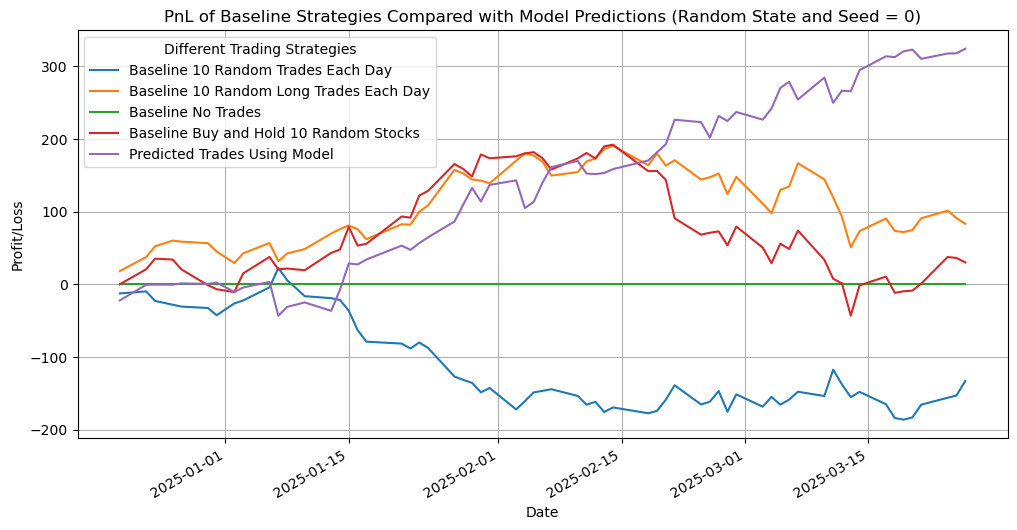

In [628]:
# Plotting a line plot for the PnL for the different strategies
stock_viz_plot = pd.DataFrame({
    'Baseline 10 Random Trades Each Day': stock_viz_baseline_10,
    'Baseline 10 Random Long Trades Each Day': stock_viz_baseline_10_long,
    'Baseline No Trades': stock_viz_baseline_nothing,
    'Baseline Buy and Hold 10 Random Stocks': stock_viz_baseline_buy_hold_10_rand,
    'Predicted Trades Using Model': stock_viz_model_10
})

stock_viz_plot.plot(figsize=(12, 6))
plt.title("PnL of Baseline Strategies Compared with Model Predictions (Random State and Seed = 0)")
plt.xlabel("Date")
plt.ylabel("Profit/Loss")
plt.legend(title="Different Trading Strategies")
plt.grid(True)
plt.show()

### Plotting outcomes using average of 1,000 random states
Now, we'll re-run our analyses and get 1000 different random states to average from.

In [629]:
# Initializing stock visualization combined np array
stock_viz_plot_combined = np.zeros((1000, 5, 64))

# Looping through 1,000 random states and seeds
for i in range(1000):
    # Setting random states and seeds
    random_state = i
    np.random.seed(i)
    
    # Getting the baseline by choosing 10 random stocks each day to trade (same as before, but getting the PnL for each day)
    stock_viz_baseline_10 = (
        stock_data_test_baseline.groupby('Date').apply(lambda g: g.sample(n=10, random_state=random_state)).reset_index(drop=True))
    stock_viz_baseline_10['Close Open Diff'] = stock_viz_baseline_10['Close'] - stock_viz_baseline_10['Open']
    stock_viz_baseline_10['Close Open Diff'] = (
        stock_viz_baseline_10['Close Open Diff'] * np.where(np.random.rand(len(stock_viz_baseline_10)) < 0.5, 1, -1))
    stock_viz_baseline_10 = stock_viz_baseline_10.groupby('Date')['Close Open Diff'].sum()
    stock_viz_plot_combined[i, 0] = np.array(stock_viz_baseline_10)

    # Getting the baseline by only buying 10 random stocks each day at Open and selling at Close (as opposed to randomly shorting as well)
    stock_viz_baseline_10_long = (
        stock_data_test_baseline.groupby('Date').apply(lambda g: g.sample(n=10, random_state=random_state)).reset_index(drop=True))
    stock_viz_baseline_10_long['Close Open Diff'] = stock_viz_baseline_10_long['Close'] - stock_viz_baseline_10_long['Open']
    stock_viz_baseline_10_long = stock_viz_baseline_10_long.groupby('Date')['Close Open Diff'].sum()
    stock_viz_plot_combined[i, 1] = np.array(stock_viz_baseline_10_long)
    
    # Getting the baseline from choosing to not buy or sell any stocks on any day
    stock_viz_baseline_nothing = pd.Series(data=0, index=stock_viz_baseline_10.index)
    stock_viz_plot_combined[i, 2] = np.array(stock_viz_baseline_nothing)
    
    # Getting the baseline for only choosing 10 random days on the first test day, buying those stocks, and then holding until the end
    stock_data_first_test_day = stock_data_test_baseline.iloc[:unique_tickers]
    random_10_stocks = stock_data_first_test_day.sample(n=10, random_state=random_state)['Ticker']
    
    stock_viz_baseline_buy_hold_10_rand = stock_data_test_baseline[stock_data_test_baseline['Ticker'].isin(random_10_stocks)]
    stock_viz_baseline_buy_hold_10_rand = stock_viz_baseline_buy_hold_10_rand.sort_values(['Ticker', 'Date'])
    stock_viz_baseline_buy_hold_10_rand['Close Diff'] = stock_viz_baseline_buy_hold_10_rand.groupby('Ticker')['Close'].diff().fillna(0)
    stock_viz_baseline_buy_hold_10_rand = stock_viz_baseline_buy_hold_10_rand.groupby('Date')['Close Diff'].sum()
    stock_viz_plot_combined[i, 3] = np.array(stock_viz_baseline_buy_hold_10_rand)
    
    # Getting the trades that we would have taken for our model (same as before, but getting the PnL for each day)
    stock_viz_model_10 = (
        stock_data_test.groupby('Date').apply(lambda g: g.sample(n=min(10, len(g)), random_state=random_state)).reset_index(drop=True))
    stock_viz_model_10['Close Open Diff'] = stock_viz_model_10['Close'] - stock_viz_model_10['Open']
    stock_viz_model_10['Close Open Diff'] = np.where(stock_viz_model_10['Predicted Label'] == 0,
        stock_viz_model_10['Close Open Diff'] * -1, stock_viz_model_10['Close Open Diff'])
    stock_viz_model_10 = stock_viz_model_10.groupby('Date')['Close Open Diff'].sum()
    stock_viz_plot_combined[i, 4] = np.array(stock_viz_model_10)

# Getting the mean of the PnLs and then performing a cumulative sum across them all
stock_viz_plot_combined = np.mean(stock_viz_plot_combined, axis=0)
stock_viz_plot_combined = np.cumsum(stock_viz_plot_combined, axis=1)

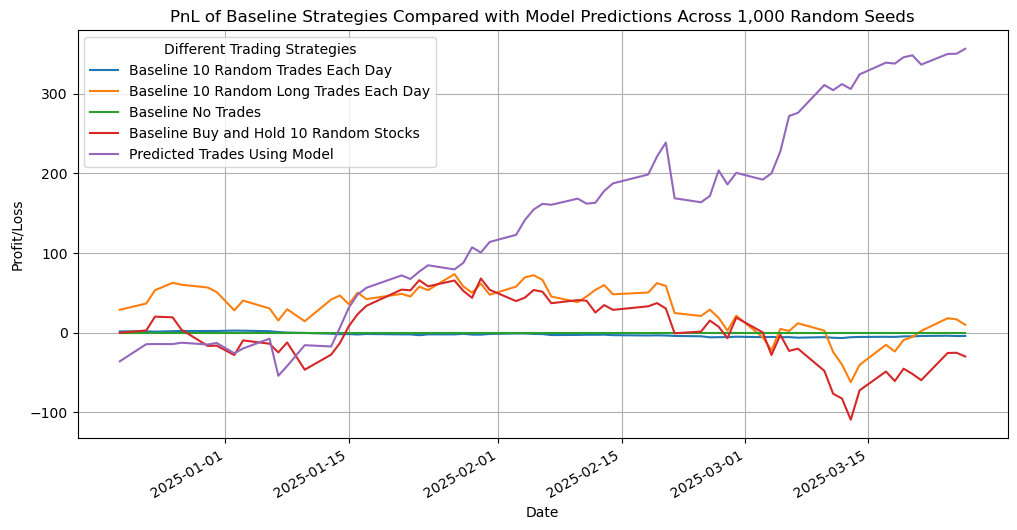

In [631]:
# Plotting a line plot for the PnL for the different strategies
stock_viz_plot_combined_df = pd.DataFrame(stock_viz_plot_combined.T, columns=['Baseline 10 Random Trades Each Day',
    'Baseline 10 Random Long Trades Each Day', 'Baseline No Trades', 'Baseline Buy and Hold 10 Random Stocks',
    'Predicted Trades Using Model'], index=stock_viz_plot.index)

stock_viz_plot_combined_df.plot(figsize=(12, 6))
plt.title("PnL of Baseline Strategies Compared with Model Predictions Across 1,000 Random Seeds")
plt.xlabel("Date")
plt.ylabel("Profit/Loss")
plt.legend(title="Different Trading Strategies")
plt.grid(True)
plt.show()

Our final PnL for the first baseline and our model predictions across the 1,000 random seeds matches what we got previously, giving us confirmation that we analyzed this properly. Furthermore, we notice that our model seems pretty robust - even our first run with a random state and seed of 0 matches pretty closely to the combined, averaged runs.

# Conclusions from Model Evaluation and Real-World Simulations
To summarize our final models and this final evaluation:
1. We built an LSTM framework that can be compiled and fitted to new training data and evaluated on the validation and test data
2. We used sliding windows to get new days of training data to fit the model to, along with new validation and test data for evaluation
   - There were ultimately 64 windows in our entire dataset, which meant that we needed to train our model 64 times from the ground up
3. For each of the 64 windows, we would have one test day that our model would evaluate; because we only cared about the long and short predictions, we extracted only the precisions for Class 0 (short) and Class 2 (long)
4. We averaged the precision scores across all 64 days for Class 0 and Class 2
5. After seeing that the precision scores were better than the baseline, we took the predictions themselves and put them to the test in a real-world simulation
   - This is not quite "real-world," but it's pretty close, as we're only using data that we would have right as the market opens and trying to predict the Close-Open difference at the end of the day
6. We would pick up to 10 random stocks to trade per day, and we would go in based on our model outputs (either long or short)
7. We found that we consistently made a profit across 1,000 random states; furthermore, we were able to beat all of our different baselines

When we initially started this project, while we were excited about learning time-series modeling and applying it to stock market prediction, we had little expectation of actually building a model that could beat it. Even after seeing our results, much of our apparent success could very likely be due to recent market conditions and what's happening in the world. Nevertheless, we have analyzed our model from both a strictly mathematical perspective and a real-world monetary perspective, and we have achieved success in both. Furthermore, our models performed better than every baseline strategy that we compared them to, and those performances were repeatable.

We do want to acknowledge that there were some major mistakes made throughout this project, notably: 1) not normalizing the data properly (the data was originally normalized against each day's Open rather than the maximum across all the days for a particular ticker), and 2) not ordering the sequences properly (by Date, and then by Ticker), which caused our training data to include days that it was not supposed to have access to. These errors cost us dozens of hours to fix (and re-train our models), and we would likely be even farther had we not made those mistakes. At this point, we have performed extensive checks to ensure that everything we have in this notebook is correct, and we even re-downloaded the data - and started from fresh - to make sure we got the same results. Now, we believe our results accurately reflect how well our model can perform, and we are confident in both the predictions that our model made and our analysis of those predictions. Overall, it was a valuable lesson in double and triple-checking our data, and we hopefully won't repeat these mistakes in the future.

We believe we have covered all of our bases in terms of how applicable this model would be to a real-life trading scenario as well:
1. We only use data that we would have right as the market opens
2. We can train a model the night before and take a few seconds to get our model outputs the day of
3. We randomly choose up to 10 stocks to trade per day, which matches how much money we might have to trade in reality
4. Our edge is noticeable, yet not extravagant, which potentially matches the vicissitudes of the market

Overall, while we would likely need to test more days because of how volatile the markets currently are, it is not unreasonable (nor infeasible) to apply this model to actual trading. The success rate will likely be lower - that's just how trading works - but there does seem to be hope for success in the long term.